# E78 · Planets around other stars, and a visitor from another star

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: (1) four years of **Kepler** photometry of the Sun-like star **Kepler-10** (NASA, via MAST: 15 quarters of 29.4-minute PDCSAP flux, 45,000 points after cleaning), with published solutions from the **NASA Exoplanet Archive**; (2) the first 46 days of **astrometry of the interstellar comet 2I/Borisov** from the **IAU Minor Planet Center** (1,513 positions from 88 observatories, one of them a satellite), with Earth, Jupiter and Saturn positions and JPL's own orbit from **JPL Horizons** |
| **You will learn** | Detrending a light curve with a robust sliding filter, and how a too-short window eats a transit · a **box least squares** transit search written in Numba, its periodogram, iterative masking, and a **false-alarm probability** from scrambled light curves with a Bayesian extreme-value fit · a **physical transit model** (limb-darkened disk, quadrature over the occulted area, tabulated and interpolated inside PyMC) and how to unit-test one · long-cadence **supersampling** · **local baselines marginalised analytically** instead of detrending · the impact parameter - stellar density **degeneracy**: a failing fit, a reparameterisation by what the data measure, and asteroseismology to break the tie · false-positive checks as **model expansion**: odd/even depths, an **occultation**, grazing geometry, Savage-Dickey ratios · **injection-recovery** and a Bayesian detection-efficiency map · orbit determination from angles only: light time, parallax, an N-body integrator in JAX inside PyMC · **short-arc ranging**: a grid over the unobservable range and range rate with the other four elements integrated out by Laplace · when is "hyperbolic" established? prior probability, posterior probability and **Bayes factors as the arc grows** · a Student-t astrometric likelihood with learned tails · 3-D posterior trajectories |

## The setting

Two of the most exciting kinds of object in astronomy are found the same way: in data that are
mostly noise, by asking which *motion* explains a faint signal.

**Planets around other stars.** When a planet passes in front of its star, the star dims by the
ratio of their areas: an Earth in front of the Sun takes away 84 parts per million (ppm) for about
thirteen hours, once a year. NASA's Kepler telescope stared at 150,000 stars for four years to catch
such dips. Kepler-10 was one of them. In 2011 it gave Kepler its first rocky planet, **Kepler-10b**:
a world 1.5 times the size of Earth that orbits its star in 20 hours, so close that its dayside must
be molten. A second, larger planet, **Kepler-10c**, transits every 45 days. We will find both
ourselves, starting from the raw light curve, and then ask the questions a discovery team asks: *how
sure are we that a dip is real, that it is a planet and not two stars eclipsing each other, how big
is it, and what could still be hiding in the data?*

**An object from another star.** On 30 August 2019 the amateur astronomer Gennady Borisov found a
comet with his home-built telescope in Crimea. Within weeks observers around the world had measured
its position hundreds of times, and it became clear that its orbit is **hyperbolic**: it is not
bound to the Sun and came from interstellar space - the second such object known, now called
**2I/Borisov**. Here we use the actual astrometry from the first 46 days to ask: from positions on
the sky alone, how do we know the orbit is open (eccentricity $e > 1$)? And how many days of data
did it take before that answer was secure?

| part | question | tool |
|---|---|---|
| A | What does a Kepler light curve look like? | cleaning, normalising, a robust sliding filter |
| B | Is there a periodic dip, and how surprised should we be? | box least squares in Numba, masking and searching again, false alarms from scrambled data, a Gumbel posterior |
| C | What is it? | a limb-darkened transit model, unit tests, supersampling, marginalised local baselines, the b-density degeneracy, a joint fit with an asteroseismic prior |
| D | Is it a planet? | odd/even depths, an occultation, grazing geometry, comparison with the Exoplanet Archive |
| E | What could we have missed? | injection-recovery and a Bayesian detection-efficiency map |
| F | Is 2I/Borisov unbound? | light time, parallax, an N-body integrator in JAX, short-arc ranging, Bayes factors against arc length, a full-arc fit in PyMC, trajectories in 3-D |

This is a teaching analysis with NumPy, Numba, JAX and PyMC only - no astronomy packages. Where the
professional analyses do more (red-noise models, pixel-level vetting, full ephemerides,
non-gravitational forces), the notebook says so.

In [1]:
import logging
import time
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numba as nb
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pymc as pm
import pytensor.tensor as pt
from matplotlib.colors import LogNorm
from pytensor import wrap_jax
from scipy import integrate, stats

from pymc_challenges import data

jax.config.update("jax_enable_x64", True)
pio.renderers.default = "plotly_mimetype+notebook_connected"
RANDOM_SEED = 78
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*object mode.*")
warnings.filterwarnings("ignore", category=integrate.IntegrationWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
T_START = time.time()

## A. The light curve

Kepler measured the brightness of Kepler-10 every 29.4 minutes ("long cadence") for four years,
with gaps: every three months the spacecraft rolled (a "quarter"), and in every fourth quarter the
star fell on a CCD module that had failed. The **PDCSAP** flux has had instrumental trends removed by
the mission pipeline by fitting them jointly across many stars. We keep cadences without quality
flags, divide each quarter by its median and express the flux in ppm.

In [2]:
data.describe("kepler10_lc")
lc = data.load("kepler10_lc")
lc = lc[(lc.quality == 0) & np.isfinite(lc.flux)].copy()
med = lc.groupby("quarter").flux.transform("median")
lc["y"] = (lc.flux / med - 1) * 1e6
lc["yerr"] = lc.flux_err / med * 1e6
t_all = lc.time.to_numpy()
y_all = lc.y.to_numpy()
print(f"{len(lc):,} cadences over {t_all.max() - t_all.min():.0f} days; "
      f"pipeline error per cadence {np.median(lc.yerr):.0f} ppm")
q = lc.groupby("quarter").agg(n=("y", "size"), start=("time", "min"), end=("time", "max"),
                              robust_sd=("y", lambda v: 1.4826 * np.median(np.abs(np.diff(v))) / np.sqrt(2)))
print(q.round(1).T.to_string())

kepler10_lc: One row per 29.4-minute cadence, all 15 quarters on the archive (Q0-Q17 minus Q8, Q12, Q16, when the star fell on the failed CCD module 3): quarter, time (BKJD = BJD_TDB - 2454833, days), flux and flux_err (PDCSAP flux: systematics-corrected aperture photometry, e-/s; NaN where missing), quality (SAP_QUALITY bit mask, 0 = no flags). 53,029 rows.
  source: NASA Kepler mission long-cadence light curves of Kepler-10 (KIC 11904151), Mikulski Archive for Space Telescopes (MAST, STScI). NASA mission data, public (MAST asks users to acknowledge MAST and the Kepler mission, funded by NASA's Science Mission Directorate). BUILT by tools/build_e78_exoplanets.py from the 15 *_llc.fits files at the URL - keep the cached file.
  url:    https://archive.stsci.edu/missions/kepler/lightcurves/0119/011904151/
45,514 cadences over 1470 days; pipeline error per cadence 38 ppm
quarter       0       1       2       3      4       5       6       7       9       10      11      13      14      1

The last row is a robust point-to-point scatter (the median absolute difference between neighbouring
cadences, rescaled): about 50 ppm per cadence, a third more than the 38 ppm the pipeline expects
from photon and read noise. The star itself adds noise - granulation and oscillations of its surface - and so do residual
instrumental effects. That extra noise is the background against which we look for dips of 150 ppm.

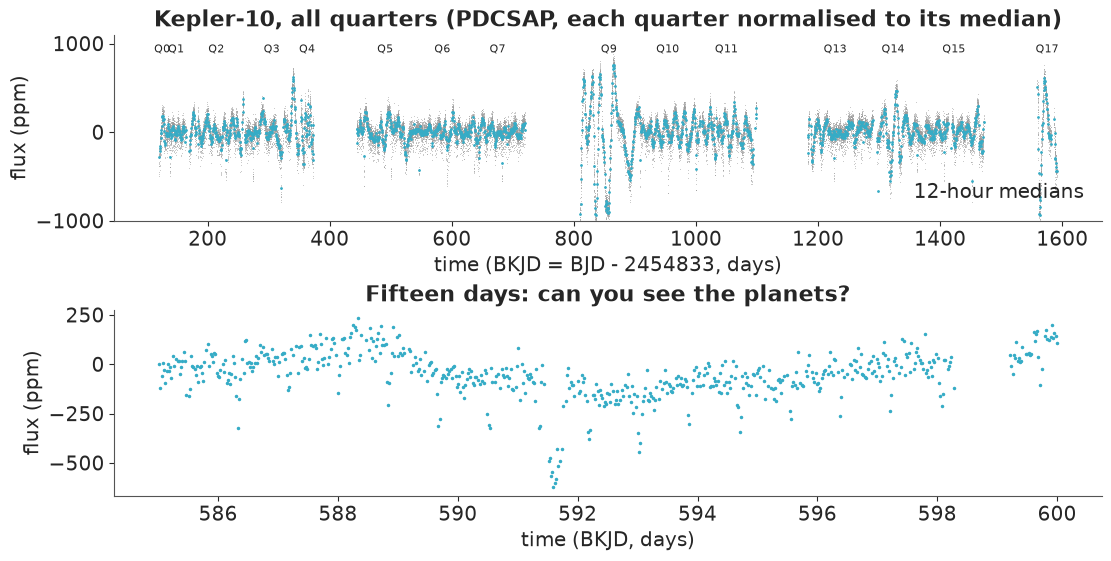

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
bins = np.arange(t_all.min(), t_all.max() + 0.5, 0.5)
idx = np.digitize(t_all, bins)
yb = pd.Series(y_all).groupby(idx).median()
tb = pd.Series(t_all).groupby(idx).mean()
axes[0].plot(t_all, y_all, ",", color="0.6", alpha=0.5)
axes[0].plot(tb, yb, ".", ms=2, color="C0", label="12-hour medians")
for qq, row in q.iterrows():
    axes[0].text((row.start + row.end) / 2, 900, f"Q{qq}", ha="center", fontsize=8)
axes[0].set(ylim=(-1000, 1100), xlabel="time (BKJD = BJD - 2454833, days)", ylabel="flux (ppm)",
            title="Kepler-10, all quarters (PDCSAP, each quarter normalised to its median)")
axes[0].legend(loc="lower right")
zoom = (t_all > 585) & (t_all < 600)
axes[1].plot(t_all[zoom], y_all[zoom], ".", ms=3, color="C0")
axes[1].set(xlabel="time (BKJD, days)", ylabel="flux (ppm)", title="Fifteen days: can you see the planets?");

Two things stand out. The flux wanders by a few hundred ppm over days to weeks - stellar
variability and what is left of the instrumental trends - and at the scale of single cadences the
scatter is comparable to the planets we are looking for. In the lower panel one dip does stand out,
near day 591.6: seven hours, about 400 ppm deep - a transit of the larger planet, 10c. The smaller
planet's transits (150 ppm for under two hours, every 20 hours) are in there too, but by eye they are
indistinguishable from the scattered low points of the noise.

### Detrending: a robust sliding filter

A transit search needs a flat light curve. We estimate the slow variation with a **sliding biweight
location** - a robust average that ignores points far from the local centre - in a window of fixed
width around each cadence, and subtract it. The window has to be much longer than a transit, or the
filter follows the dip and removes part of it. The longest transit we will look for (a 100-day orbit
around a Sun-like star) lasts about 8 hours, so we take a **1-day window**; Part B shows what happens
with shorter ones.

robust sd of the detrended flux: 57.4 ppm; 5 upward outliers clipped


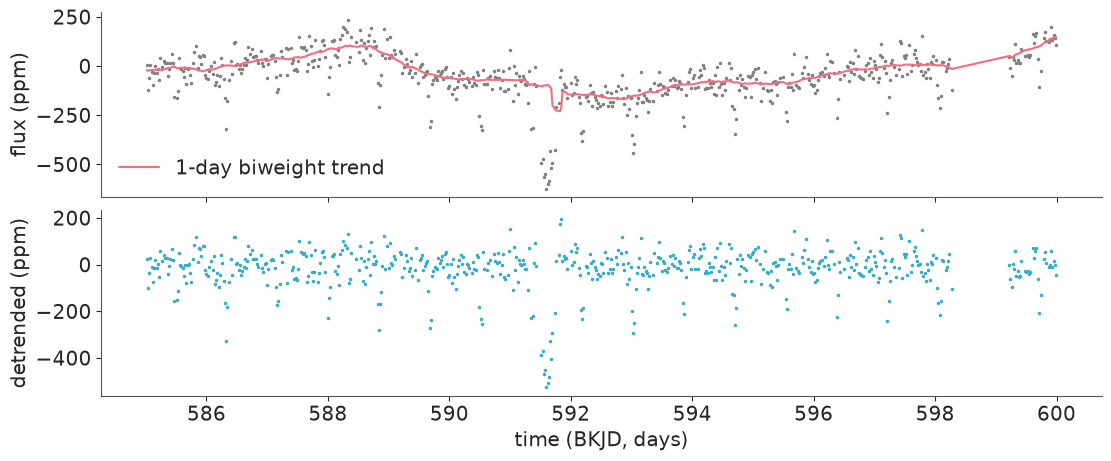

In [4]:
@nb.njit(cache=True)
def _biweight_loc(x, c=5.0):
    m = np.median(x)
    for _ in range(5):
        mad = np.median(np.abs(x - m))
        if mad == 0:
            return m
        num = 0.0
        den = 0.0
        for i in range(len(x)):
            u = (x[i] - m) / (c * mad)
            if abs(u) < 1:
                w = (1 - u * u) ** 2
                num += w * (x[i] - m)
                den += w
        if den == 0:
            return m
        m = m + num / den
    return m


@nb.njit(parallel=True, cache=True)
def biweight_trend(t, y, use, window):
    """Sliding biweight location of y within +-window/2 of each point, from points with use=True."""
    n = len(t)
    out = np.empty(n)
    lo = np.searchsorted(t, t - window / 2)
    hi = np.searchsorted(t, t + window / 2)
    for i in nb.prange(n):
        seg = y[lo[i]:hi[i]][use[lo[i]:hi[i]]]
        out[i] = _biweight_loc(seg) if len(seg) > 3 else np.nan
    return out


trend = biweight_trend(t_all, y_all, np.ones(len(t_all), bool), 1.0)
resid = y_all - trend
SIG = 1.4826 * np.median(np.abs(resid))
keep = resid < 5 * SIG            # clip upward outliers only: a transit is a DOWNWARD excursion
t_all, y_all, resid, trend = t_all[keep], y_all[keep], resid[keep], trend[keep]
print(f"robust sd of the detrended flux: {SIG:.1f} ppm; {np.sum(~keep)} upward outliers clipped")

fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
zoom = (t_all > 585) & (t_all < 600)
axes[0].plot(t_all[zoom], y_all[zoom], ".", ms=3, color="0.5")
axes[0].plot(t_all[zoom], trend[zoom], color="C1", label="1-day biweight trend")
axes[0].legend()
axes[0].set(ylabel="flux (ppm)")
axes[1].plot(t_all[zoom], resid[zoom], ".", ms=3, color="C0")
axes[1].set(xlabel="time (BKJD, days)", ylabel="detrended (ppm)");

Only upward outliers are clipped (cosmic rays, a few bad cadences): clipping downward ones at
5 sigma would also remove the deepest points of a large planet's transits. Look at the trend line at
day 591.6: even the 1-day filter dips a little into 10c's transit - the first sign of a problem we
measure in Part B.

## B. The search: box least squares

A transit, seen from far enough away, is a **box**: the flux drops by a depth $\delta$ for a
duration $d$, once per period $P$. For given $(P, d, t_0)$ the best depth is the weighted mean flux
inside the box, and the improvement in $\chi^2$ over "no transit" is

$$\Delta\chi^2 = \frac{S^2}{W}\,\frac{W_\text{tot}}{W_\text{tot} - W},\qquad
S = \sum_{\text{in box}} w_i (y_i - \bar y),\quad W = \sum_{\text{in box}} w_i,$$

with weights $w_i = 1/\sigma^2$. **Box least squares** (BLS; Kovacs, Zucker & Mazeh 2002) evaluates
this for every period on a grid: fold the light curve at $P$, bin it in phase, and slide boxes of
several durations along the bins. We report $\text{SNR} = \sqrt{\Delta\chi^2}$ - how many standard
errors deep the best box is. Two details decide whether a search works:

* **the period grid** must be fine enough that, over the four-year baseline $T$, a trial period
  drifts out of phase by less than a fraction of a transit duration: $\Delta P \approx P\,d/(2T)$.
  Short periods and short transits need the finest steps: 300,000 periods between 0.5 and 100 days;
* **the durations** are restricted to what a planet on that orbit around a Sun-like star can have
  (0.4 to 1.6 times the central duration $d_0 = P/(\pi\,a/R_\star)$), so that long boxes are not
  tried at short periods where they would fit stellar noise.

In [5]:
@nb.njit(parallel=True, cache=True)
def bls(t, y, w, periods, dur_lo, dur_hi, durations, dbin):
    """Box least squares. For each period: the best dip over epochs and allowed durations.
    Returns dchi2, duration, mid-time and depth of the best box."""
    n = len(t)
    wsum = w.sum()
    ybar = (w * y).sum() / wsum
    tref = t[0]
    tt = t - tref
    npd = len(periods)
    power = np.zeros(npd)
    bdur = np.zeros(npd)
    bt0 = np.zeros(npd)
    bdep = np.zeros(npd)
    for ip in nb.prange(npd):
        P = periods[ip]
        nbins = int(np.ceil(P / dbin))
        binw = P / nbins
        invP = 1.0 / P
        sw = np.zeros(nbins)
        sy = np.zeros(nbins)
        for i in range(n):
            ph = tt[i] * invP
            ph -= np.floor(ph)
            b = min(int(ph * nbins), nbins - 1)
            sw[b] += w[i]
            sy[b] += w[i] * (y[i] - ybar)
        best = 0.0
        for idur in range(len(durations)):
            if durations[idur] < dur_lo[ip] or durations[idur] > dur_hi[ip]:
                continue
            k = int(np.round(durations[idur] / binw))
            if k < 1 or k >= nbins // 2:
                continue
            W = 0.0
            S = 0.0
            for j in range(k):
                W += sw[j]
                S += sy[j]
            for j0 in range(nbins):
                if W > 0 and S < 0:
                    p = S * S / W * wsum / (wsum - W)
                    if p > best:
                        best = p
                        bdur[ip] = k * binw
                        bt0[ip] = tref + (j0 + k / 2) * binw
                        bdep[ip] = -S / W
                jin = (j0 + k) % nbins
                W += sw[jin] - sw[j0]
                S += sy[jin] - sy[j0]
        power[ip] = best
    return power, bdur, bt0, bdep


G_CGS = 6.674e-8
CADENCE = CAD_DAYS = 29.4244 / 1440           # Kepler long cadence, days


def d0_days(P, rho=1.41):
    """Central transit duration (days) of a small planet around a star of mean density rho (g/cm3)."""
    aR = (G_CGS * rho * (P * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    return P / (np.pi * aR)


def period_grid(pmin, pmax, T, oversample=2.0):
    ps = [pmin]
    while ps[-1] < pmax:
        ps.append(ps[-1] * (1 + 0.4 * d0_days(ps[-1]) / (oversample * T)))
    return np.array(ps)


DURS = np.array([1, 1.25, 1.5, 2, 2.5, 3, 3.5, 4, 5, 6, 7, 8.5, 10, 12, 14]) / 24


def run_bls(t, y, periods, sig=SIG):
    d0 = d0_days(periods)
    pw, dur, t0, dep = bls(t, y, np.full(len(t), sig**-2), periods, 0.4 * d0, 1.6 * d0, DURS, 1 / 72)
    return pd.DataFrame({"P": periods, "snr": np.sqrt(pw), "dur": dur, "t0": t0, "depth": dep})


def fold_phase(t, P, t0):
    """Time from the nearest transit centre (days)."""
    return (t - t0 + 0.5 * P) % P - 0.5 * P


PERIODS = period_grid(0.5, 100, t_all.max() - t_all.min())
print(f"{len(PERIODS):,} trial periods")
tic = time.time()
search = []
t_s, r_s = t_all.copy(), resid.copy()
for it in range(3):
    res = run_bls(t_s, r_s, PERIODS)
    best = res.loc[res.snr.idxmax()]
    sde = (best.snr - res.snr.mean()) / res.snr.std()
    search.append((res, best, t_s.copy(), r_s.copy()))
    print(f"search {it + 1}: P = {best.P:.5f} d, duration {best.dur * 24:.1f} h, depth {best.depth:.0f} ppm, "
          f"SNR {best.snr:.1f}, SDE {sde:.1f}")
    # mask this signal (1.5 durations either side of each transit) and detrend again
    m = np.abs(fold_phase(t_s, best.P, best.t0)) < 1.5 * best.dur
    y_s = y_all[np.isin(t_all, t_s)][~m]
    t_s = t_s[~m]
    r_s = y_s - biweight_trend(t_s, y_s, np.ones(len(t_s), bool), 1.0)
print(f"three searches: {time.time() - tic:.0f} s")

304,594 trial periods

search 1: P = 0.83750 d, duration 1.6 h, depth 154 ppm, SNR 170.6, SDE 38.9


search 2: P = 45.29468 d, duration 6.0 h, depth 379 ppm, SNR 98.4, SDE 32.6


search 3: P = 60.67467 d, duration 3.0 h, depth 56 ppm, SNR 6.8, SDE 5.3
three searches: 14 s


search 3, five highest peaks: P = 60.6747 d (SNR 6.8), P = 0.8375 d (SNR 6.7), P = 91.7179 d (SNR 6.6), P = 0.5583 d (SNR 6.5), P = 67.0950 d (SNR 6.5)
SNR of a single transit of the 0.84-day signal: about 4.9


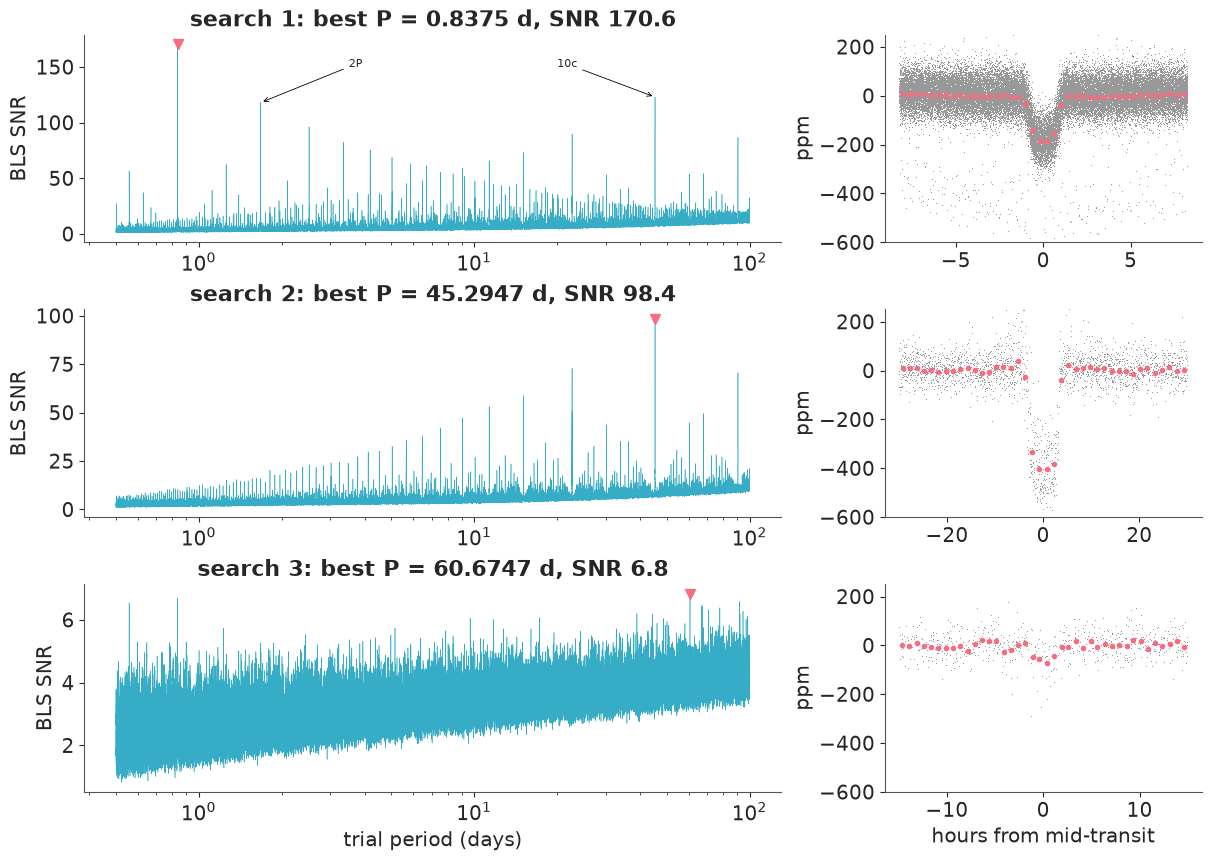

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8.5), gridspec_kw={"width_ratios": [2.2, 1]})
for i, (res, best, t_s, r_s) in enumerate(search):
    ax = axes[i, 0]
    ax.plot(res.P, res.snr, lw=0.4, color="C0")
    ax.plot(best.P, best.snr, "v", color="C1", ms=7)
    ax.set(xscale="log", ylabel="BLS SNR", xlabel="trial period (days)" if i == 2 else None,
           title=f"search {i + 1}: best P = {best.P:.4f} d, SNR {best.snr:.1f}")
    ph = fold_phase(t_s, best.P, best.t0) * 24
    w = np.abs(ph) < 5 * best.dur * 24
    ax = axes[i, 1]
    ax.plot(ph[w], r_s[w], ",", color="0.6")
    edges = np.linspace(-5 * best.dur * 24, 5 * best.dur * 24, 41)
    k = np.digitize(ph[w], edges)
    yb = pd.Series(r_s[w]).groupby(k).mean()
    xb = pd.Series(ph[w]).groupby(k).mean()
    ax.plot(xb, yb, "o", ms=3, color="C1")
    ax.set(ylim=(-600, 250), xlabel="hours from mid-transit" if i == 2 else None, ylabel="ppm")
axes[0, 0].annotate("2P", xy=(2 * search[0][1].P, 118), xytext=(3.5, 150), fontsize=8,
                    arrowprops=dict(arrowstyle="->", lw=0.6))
axes[0, 0].annotate("10c", xy=(45.3, 123), xytext=(20, 150), fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.6))
res3 = search[2][0]
peaks = res3.sort_values("snr", ascending=False)
top = []
for row in peaks.itertuples():            # five highest peaks at clearly different periods
    if all(abs(row.P / p_ - 1) > 0.01 for p_ in top):
        top.append(row.P)
    if len(top) == 5:
        break
print("search 3, five highest peaks:", ", ".join(f"P = {p_:.4f} d (SNR {res3.snr[res3.P == p_].iloc[0]:.1f})" for p_ in top))
single = search[0][1].depth / SIG * np.sqrt(search[0][1].dur / CAD_DAYS)
print(f"SNR of a single transit of the 0.84-day signal: about {single:.1f}");

**Search 1** finds a dip every **0.8375 days**, 150 ppm deep and 1.6 hours long, at an SNR of 170: a
signal no one could miss once the whole light curve is folded, although a single transit (SNR about
5, printed above) would drown among the many noise dips of that size in four years of data. Multiples
of the period (2P, 3P, ...) stand out too - folding at 2P still stacks every other transit - and so
does 10c at 45 days, already the second-highest peak. After masking 10b's transits, **search 2**
finds that second dip every **45.29 days**, 380 ppm deep and 6 hours long, SNR near 100: Kepler-10c,
with its own period multiples and fractions. After masking both, **search 3** has nothing of that
kind: its highest peaks are below SNR 7 (printed above). One of them sits at 10b's own period, 0.8375
days - its transits were masked, but something else repeats at that period; Part D finds it.

The periodogram of search 3 looks like noise. But how high do noise peaks get when we search 300,000
periods? The SNR assumes white noise with a known sd; real light curves have correlated noise, and
the largest of 300,000 correlated trials is not a 3-sigma event. The **signal detection efficiency**
(SDE, the peak's distance from the periodogram mean in units of its sd) is a common rule of thumb.
Better is to run the *same search* on data that contain no transits but keep the noise: here the
search-3 residuals **rolled** by a random number of cadences relative to their timestamps. Each roll
keeps the noise's character (and the gaps) but breaks any periodicity. The maximum SNR of each
scrambled search is one draw from the null distribution of "the best peak when nothing is there".

In [7]:
tic = time.time()
t_null, r_null = search[2][2], search[2][3]
null_max = []
for j in range(8):
    shift = rng.integers(500, len(r_null) - 500)
    res = run_bls(t_null, np.roll(r_null, shift), PERIODS)
    null_max.append(res.snr.max())
null_max = np.array(null_max)
print("maximum SNR in 8 scrambled searches:", np.round(np.sort(null_max), 2), f"({time.time() - tic:.0f} s)")

maximum SNR in 8 scrambled searches: [6.56 6.6  6.64 6.81 6.81 6.85 7.13 7.17] (39 s)


Eight numbers are too few to read a 1% false-alarm threshold off directly. Maxima of many weakly
dependent trials follow an **extreme-value (Gumbel) distribution**, so we fit one - with its
uncertainty, which with eight draws is the point - and ask for the posterior of (a) the SNR a pure
noise search exceeds 1% of the time, and (b) the false-alarm probability of each observed peak.

In [8]:
with pm.Model() as gumbel_model:
    mu = pm.Normal("mu", 7.0, 2.0)
    beta = pm.HalfNormal("beta", 1.0)
    pm.Gumbel("max_snr", mu=mu, beta=beta, observed=null_max)
    thr = pm.Deterministic("thr_1pct", mu - beta * np.log(-np.log(0.99)))
    idata_gumbel = pm.sample(random_seed=RANDOM_SEED, progressbar=False)

post = az.extract(idata_gumbel, var_names=["mu", "beta", "thr_1pct"])
mu_d, beta_d = post["mu"].values, post["beta"].values
thr_d = post["thr_1pct"].values
SNR_THR = float(np.median(thr_d))
print(f"1% false-alarm SNR threshold: median {SNR_THR:.2f}, 90% interval "
      f"{np.quantile(thr_d, 0.05):.2f} to {np.quantile(thr_d, 0.95):.2f}")
for i, (_, best, _, _) in enumerate(search):
    fap = 1 - np.exp(-np.exp(-(best.snr - mu_d) / beta_d))
    print(f"search {i + 1} peak SNR {best.snr:6.1f}: false-alarm probability median {np.median(fap):.2g}, "
          f"95% upper {np.quantile(fap, 0.95):.2g}")

1% false-alarm SNR threshold: median 7.71, 90% interval 7.29 to 8.56
search 1 peak SNR  170.6: false-alarm probability median 0, 95% upper 0
search 2 peak SNR   98.4: false-alarm probability median 0, 95% upper 0
search 3 peak SNR    6.8: false-alarm probability median 0.45, 95% upper 0.69


The two planets are beyond any conceivable noise peak (false-alarm probabilities that underflow to
zero), and the search-3 peak is a typical noise maximum. The threshold itself is uncertain by more
than half an SNR unit (90%: 7.3 to 8.6) from eight scrambles; more scrambles would narrow it, at 5
seconds each. We use
the posterior median as the detection threshold in Part E.

### A failure worth seeing: the detrending window

Now that we know where 10c's transits are, we can check what detrending did to them. Below, the
light curve is detrended with windows from 0.3 to 3 days, with the transits either included in the
filter's input (as in a blind search) or **masked** from it (the trend is then interpolated across
them), and 10c's depth is measured from the fold.

transits masked  False  True 
window (d)                   
0.30              18.0    NaN
0.50             200.0    NaN
0.75             328.0    NaN
1.00             419.0  465.0
1.50             444.0  456.0
2.00             447.0  458.0
3.00             441.0  455.0


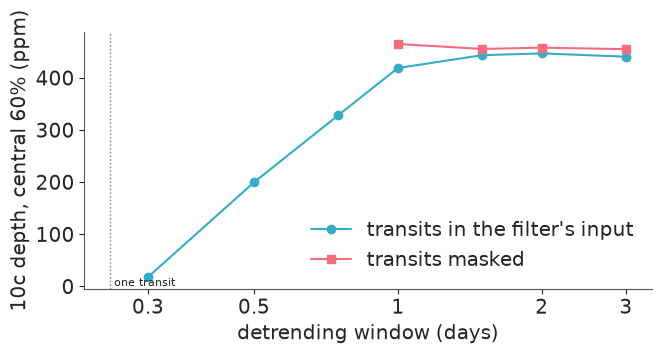

In [9]:
Pc, t0c, durc = search[1][1].P, search[1][1].t0, search[1][1].dur
Pb, t0b, durb = search[0][1].P, search[0][1].t0, search[0][1].dur
in_c = np.abs(fold_phase(t_all, Pc, t0c)) < 0.3 * durc
near_b = np.abs(fold_phase(t_all, Pb, t0b)) < 1.5 * durb
near_c = np.abs(fold_phase(t_all, Pc, t0c)) < 1.5 * durc
rows = []
for win in [0.3, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    for masked in [False, True]:
        if masked and win < 1.0:      # the masked stretch is 0.75 d long: shorter windows see no data there
            continue
        use = ~(near_b | near_c) if masked else np.ones(len(t_all), bool)
        tr = biweight_trend(t_all, y_all, use, win)
        rows.append({"window (d)": win, "transits masked": masked,
                     "10c depth (ppm)": -np.nanmean((y_all - tr)[in_c & ~near_b])})
depth_tab = pd.DataFrame(rows).pivot(index="window (d)", columns="transits masked", values="10c depth (ppm)")
print(depth_tab.round(0))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(depth_tab.index, depth_tab[False], "o-", label="transits in the filter's input")
ax.plot(depth_tab.index, depth_tab[True], "s-", label="transits masked")
ax.axvline(durc, color="0.5", ls=":", lw=1)
ax.text(durc, ax.get_ylim()[0], " one transit", fontsize=8, va="bottom")
ax.set(xlabel="detrending window (days)", ylabel="10c depth, central 60% (ppm)", xscale="log")
ax.set_xticks([0.3, 0.5, 1, 2, 3], ["0.3", "0.5", "1", "2", "3"])
ax.minorticks_off()
ax.legend();

With a 0.3-day window - about the length of 10c's transit - the filter follows the dip and removes
almost all of it; at half a day more than half is gone, and even at the 1-day window we searched with,
the unmasked depth is about 10% shallower than the masked one. (Masking needs a window longer than the
masked stretch, three transit durations, or there is nothing left to estimate the trend from.) For the
*search* this matters little (SNR 100 is SNR 100). For *measuring* the planet it matters a lot: the
radius goes as the square root of the depth. So in Part C we do not fit a detrended light curve at
all. We fit the raw flux near each transit, with its own local baseline, jointly with the transit.

## C. What is it? A physical transit model

A planet is not a box. It has a size $k = R_p/R_\star$ relative to the star; it crosses the stellar
disk along a chord at **impact parameter** $b$ (the closest approach to the disk centre, in stellar
radii); and the star is **limb-darkened**: its edge is dimmer than its centre, so the dip is rounded
("U-shaped") and deeper in the middle. With the quadratic law

$$I(\mu) = 1 - u_1 (1-\mu) - u_2 (1-\mu)^2,\qquad \mu = \sqrt{1 - r^2},$$

the fraction of light blocked when the planet's centre is at projected separation $z$ (in stellar
radii) is the integral of $I$ over the part of the stellar disk the planet covers. In polar
coordinates about the star's centre, a ring of radius $r$ is covered over an arc of angle
$2\alpha(r)$, with $\cos\alpha = (r^2 + z^2 - k^2)/(2rz)$, so

$$\lambda(z) = \frac{1}{\pi\,(1 - u_1/3 - u_2/6)}\left[\int_{|z-k|}^{\min(z+k,\,1)} I(r)\,2\alpha(r)\,r\,dr
  \; + \; \mathbb 1[z<k]\int_0^{k-z} I(r)\,2\pi r\,dr\right].$$

Mandel & Agol (2002) solved this in closed form with elliptic integrals; we integrate numerically
with 16-point Gauss-Legendre quadrature after the substitution $r = \bar r - h\cos\theta$, which
smooths the square-root behaviour at both ends of the interval. The first job with any hand-written
likelihood component is to **test it** against things we know exactly:

In [10]:
GL_X, GL_W = np.polynomial.legendre.leggauss(16)
TH = (GL_X + 1) * np.pi / 2           # theta nodes on (0, pi)
TW = GL_W * np.pi / 2


def blocked_np(z, k, u1, u2):
    """Fraction of the flux of a quadratically limb-darkened star blocked by an opaque disk."""
    z = np.maximum(np.asarray(z, float), 1e-9)
    r0, r1 = np.abs(z - k), np.minimum(z + k, 1.0)
    half = np.maximum(r1 - r0, 0) / 2
    r = ((r0 + r1) / 2)[..., None] - half[..., None] * np.cos(TH)
    dr = half[..., None] * np.sin(TH)
    alpha = np.arccos(np.clip((r**2 + z[..., None] ** 2 - k**2) / (2 * r * z[..., None] + 1e-300), -1, 1))
    mu = np.sqrt(np.maximum(1 - r**2, 0))
    part = ((1 - u1 * (1 - mu) - u2 * (1 - mu) ** 2) * 2 * alpha * r * dr * TW).sum(-1)
    R = np.maximum(k - z, 0) / 2          # disk of radius k - z fully covered when z < k
    rr = R[..., None] * (1 - np.cos(TH))
    mu2 = np.sqrt(np.maximum(1 - rr**2, 0))
    full = ((1 - u1 * (1 - mu2) - u2 * (1 - mu2) ** 2) * 2 * np.pi * rr * R[..., None] * np.sin(TH) * TW).sum(-1)
    return (part + full) / (np.pi * (1 - u1 / 3 - u2 / 6))


def uniform_overlap(z, k):
    """Exact overlap area / pi of two disks (radii 1 and k): the uniform-source transit."""
    z = np.asarray(z, float)
    out = np.where(z <= 1 - k, k**2, 0.0)
    part = (z > abs(1 - k)) & (z < 1 + k)
    zz = z[part]
    k0 = np.arccos((k**2 + zz**2 - 1) / (2 * k * zz))
    k1 = np.arccos((1 - k**2 + zz**2) / (2 * zz))
    out[part] = (k**2 * k0 + k1 - 0.5 * np.sqrt(4 * zz**2 - (1 + zz**2 - k**2) ** 2)) / np.pi
    return out


def blocked_bruteforce(z, k, u1, u2):
    """Reference: 2-D adaptive integration of I over the planet's disk."""
    def f(s, phi):
        x, y = z + s * np.cos(phi), s * np.sin(phi)
        r2 = x * x + y * y
        if r2 >= 1:
            return 0.0
        mu = np.sqrt(1 - r2)
        return (1 - u1 * (1 - mu) - u2 * (1 - mu) ** 2) * s
    val, _ = integrate.dblquad(f, 0, 2 * np.pi, 0, k, epsabs=1e-13, epsrel=1e-10)
    return val / (np.pi * (1 - u1 / 3 - u2 / 6))


zs = np.array([0.0, 0.006, 0.02, 0.4, 0.9, 0.975, 0.99, 1.0, 1.015])
print("uniform source vs exact overlap, max |error| / k^2:",
      f"{np.abs(blocked_np(zs, 0.02, 0, 0) - uniform_overlap(zs, 0.02)).max() / 0.02**2:.1e}")
errs = [abs(blocked_np(np.array([z]), 0.02, 0.45, 0.2)[0] - blocked_bruteforce(z, 0.02, 0.45, 0.2)) / 0.02**2
        for z in [0.0, 0.01, 0.5, 0.98, 1.0, 1.01]]
print(f"limb-darkened vs 2-D brute force (k = 0.02), max |error| / k^2: {max(errs):.1e}")
small = blocked_np(np.array([0.0]), 1e-3, 0.45, 0.2)[0] / (1e-6 / (1 - 0.45 / 3 - 0.2 / 6))
print(f"small-planet limit at disk centre (should be 1): {small:.6f}")

uniform source vs exact overlap, max |error| / k^2: 1.2e-12


limb-darkened vs 2-D brute force (k = 0.02), max |error| / k^2: 3.7e-07
small-planet limit at disk centre (should be 1): 1.000000


The uniform-source case matches the exact overlap area to rounding error, the limb-darkened case
matches a brute-force 2-D integration to better than one part in a million of the depth (the
reference integrator itself warns near the limb, so that is an upper bound on our error), and a
tiny planet at disk centre blocks exactly $k^2 I(1)$ over the disk-averaged intensity.

### Shapes, and what a 29.4-minute exposure does to them

The left panel shows how the transit shape changes with the impact parameter: central transits
are long and U-shaped; as $b \to 1$ the chord shortens and, once the planet only grazes the limb
($b > 1 - k$), the dip becomes **V-shaped** and shallow. The right panel shows why long cadence
needs care: each Kepler point is a 29.4-minute average, longer than 10b's ingress (about two
minutes), so we average the model over several sub-exposures ("supersampling"; Kipping 2010).

 5 sub-steps vs 41: largest difference 6.9 ppm, rms over the transit 2.5 ppm
11 sub-steps vs 41: largest difference 1.7 ppm, rms over the transit 0.7 ppm


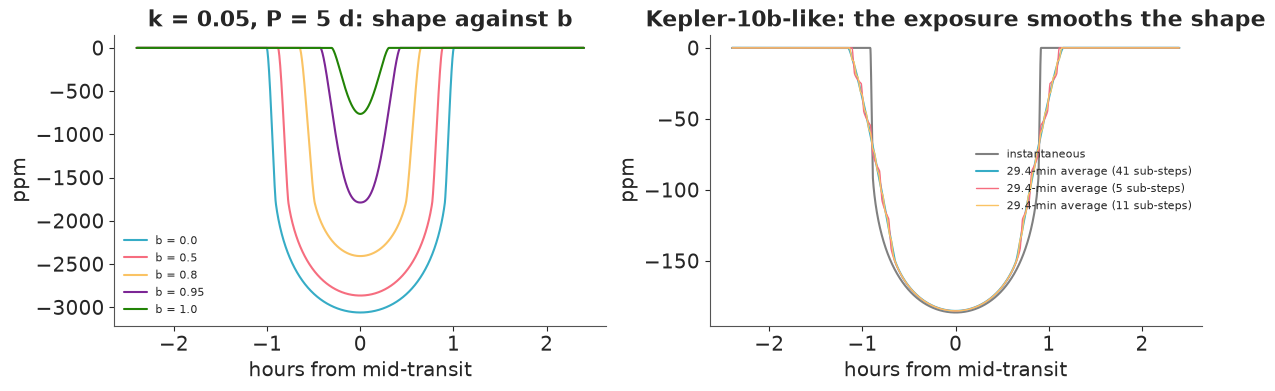

In [11]:
def z_of_t(t, P, t0, aR, b):
    ph = 2 * np.pi * (t - t0) / P
    return np.where(np.cos(ph) > 0, np.sqrt(aR**2 * np.sin(ph) ** 2 + b**2 * np.cos(ph) ** 2), 10.0)


def offsets(n):
    """Sub-exposure times (days) that average a model over one long-cadence exposure."""
    return (np.arange(n) - (n - 1) / 2) / n * CADENCE


NSUB = {"b": 11, "c": 5}
aR_b_guess = (G_CGS * 1.068 * (Pb * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
tt = np.linspace(-0.1, 0.1, 2001)
for b_ in [0.0, 0.5, 0.8, 0.95, 1.0]:
    aR = 20.0
    axes[0].plot(tt * 24, -1e6 * blocked_np(z_of_t(tt, 5.0, 0, aR, b_), 0.05, 0.45, 0.2), label=f"b = {b_}")
axes[0].set(xlabel="hours from mid-transit", ylabel="ppm", title="k = 0.05, P = 5 d: shape against b")
axes[0].legend(fontsize=8)
inst = -1e6 * blocked_np(z_of_t(tt, Pb, 0, aR_b_guess, 0.33), 0.0125, 0.45, 0.2)
ax = axes[1]
ax.plot(tt * 24, inst, color="0.5", label="instantaneous")
dev = {}
for ns in [41, 5, 11]:
    sm = -1e6 * blocked_np(z_of_t(tt[:, None] + offsets(ns), Pb, 0, aR_b_guess, 0.33), 0.0125, 0.45, 0.2).mean(1)
    dev[ns] = sm
    ax.plot(tt * 24, sm, label=f"29.4-min average ({ns} sub-steps)", lw=1.5 if ns == 41 else 1)
for ns in [5, 11]:
    d = (dev[ns] - dev[41])[np.abs(dev[41]) > 0]
    print(f"{ns:2d} sub-steps vs 41: largest difference {np.abs(d).max():.1f} ppm, rms over the transit {np.sqrt(np.mean(d**2)):.1f} ppm")
ax.set(xlabel="hours from mid-transit", ylabel="ppm", title="Kepler-10b-like: the exposure smooths the shape")
ax.legend(fontsize=8);

How many sub-steps? Compare with the precision the fit can reach: 10b has about 4,000 in-transit
points at ~55 ppm, so its average shape is known to roughly 55/sqrt(4000), about 1 ppm. Five
sub-steps get the shape wrong by a few ppm around the contact points - comparable to that precision,
so a bias we would carry into $b$ and $k$. Eleven sub-steps are within about 0.7 ppm rms of 41; we use
11 for 10b and 5 for 10c, whose ingress lasts about ten minutes and which has only 26 transits in the data.

### A transit model PyMC can differentiate, quickly

Evaluating the 16-node quadrature at each of the ~120,000 supersampled times near transits, at every
gradient, is slow. But for a given $(k, u_1, u_2)$ the blocked fraction depends on $z$ alone. So inside the model we compute
$\lambda$ on a fixed grid of 265 values of a rescaled separation $s$ ($s \in [0, 1]$ maps to
$z \in [0, 1-k]$, $s \in [1, 2]$ to the ingress $z \in [1-k, 1+k]$) and **interpolate linearly** -
about 8,500 quadrature nodes per table instead of about two million. The interpolation error (checked
below against direct evaluation) is a fraction of a ppm. (`pt.interp` exists, but it builds a
data x grid comparison matrix: in a first version with ~175,000 interpolated points it used 2.9 GB
and 230 ms per gradient. Indexing the uniform pieces directly costs a few ms.)

In [12]:
S_GRID = np.r_[np.linspace(0, 1, 201)[:-1], np.linspace(1, 2, 65)]


def s_to_z_np(s, k):
    return np.where(s < 1, s * (1 - k), 1 - k + (s - 1) * 2 * k)


def blocked_table(k, u1, u2):
    """The blocked fraction on S_GRID, as a PyTensor graph (same quadrature as blocked_np)."""
    s = pt.as_tensor(S_GRID)
    z = pt.maximum(pt.switch(s < 1, s * (1 - k), 1 - k + (s - 1) * 2 * k), 1e-9)
    r0, r1 = pt.abs(z - k), pt.minimum(z + k, 1.0)
    half = pt.maximum(r1 - r0, 0) / 2
    r = ((r0 + r1) / 2)[:, None] - half[:, None] * np.cos(TH)
    dr = half[:, None] * np.sin(TH)
    c = pt.clip((r**2 + z[:, None] ** 2 - k**2) / (2 * r * z[:, None]), -1 + 1e-12, 1 - 1e-12)
    mu = pt.sqrt(pt.maximum(1 - r**2, 1e-12))
    part = ((1 - u1 * (1 - mu) - u2 * (1 - mu) ** 2) * 2 * pt.arccos(c) * r * dr * TW).sum(-1)
    R = pt.maximum(k - z, 0) / 2
    rr = R[:, None] * (1 - np.cos(TH))
    mu2 = pt.sqrt(pt.maximum(1 - rr**2, 1e-12))
    full = ((1 - u1 * (1 - mu2) - u2 * (1 - mu2) ** 2) * 2 * np.pi * rr * R[:, None] * np.sin(TH) * TW).sum(-1)
    return (part + full) / (np.pi * (1 - u1 / 3 - u2 / 6))


def interp_blocked(z, k, tab):
    """Linear interpolation in s on the piecewise-uniform grid (200 steps on [0,1), 64 on [1,2])."""
    s = pt.clip(pt.switch(z < 1 - k, z / (1 - k), 1 + (z - (1 - k)) / (2 * k)), 0, 2)
    x = pt.switch(s < 1, s * 200, 200 + (s - 1) * 64)
    j = pt.clip(pt.floor(x), 0, len(S_GRID) - 2).astype("int64")
    w = x - j
    return tab[j] * (1 - w) + tab[j + 1] * w


# the same interpolation in NumPy, against direct quadrature
zz = np.linspace(0, 1.03, 3000)
tab_np = blocked_np(np.maximum(s_to_z_np(S_GRID, 0.0125), 1e-9), 0.0125, 0.45, 0.2)
sv = np.clip(np.where(zz < 1 - 0.0125, zz / (1 - 0.0125), 1 + (zz - (1 - 0.0125)) / 0.025), 0, 2)
xv = np.where(sv < 1, sv * 200, 200 + (sv - 1) * 64)
jv = np.clip(np.floor(xv), 0, len(S_GRID) - 2).astype(int)
approx = tab_np[jv] * (1 - (xv - jv)) + tab_np[jv + 1] * (xv - jv)
print(f"interpolation error, k = 0.0125: max {1e6 * np.abs(approx - blocked_np(zz, 0.0125, 0.45, 0.2)).max():.2f} ppm")

interpolation error, k = 0.0125: max 0.17 ppm


### No detrending: local baselines, integrated out

We fit the *raw* normalised flux in windows around each transit - 0.32 days wide for 10b, 1.2 days
for 10c - plus windows around 10b's **phase 0.5**, where the planet passes *behind* the star (Part D
needs them). Each window $j$ gets its own polynomial baseline (a line, or a quadratic for windows
longer than half a day) with coefficients $c_j$. With a flat prior on $c_j$ and white noise of sd
$\sigma$, the coefficients integrate out exactly: if the columns of $Q_j$ are an orthonormal basis for
the window's polynomials, the marginal log-likelihood of the residuals $r = y - \text{transit}$ is

$$\log p(y) = -\frac{1}{2\sigma^2}\Big(\lVert r\rVert^2 - \sum_j \lVert Q_j^\top r_j\rVert^2\Big)
  - (N - p)\log\sigma + \text{const},$$

where $p$ is the number of baseline coefficients. Five thousand nuisance parameters disappear, the
stellar variability within each window is fitted *jointly* with the transit, and nothing is
subtracted in advance. The sums $Q_j^\top r_j$ are differences of a cumulative sum, which PyTensor
differentiates cheaply.

In [13]:
def make_windows(t, y, centres, halfwidths):
    """Points within the (merged) windows; per-window orthonormal polynomial bases."""
    iv = sorted((c - h, c + h) for c, h in zip(centres, halfwidths))
    merged = []
    for a, b in iv:
        if merged and a <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], b)
        else:
            merged.append([a, b])
    merged = np.array(merged)
    j = np.searchsorted(merged[:, 0], t, side="right") - 1
    inw = (j >= 0) & (t <= merged[np.maximum(j, 0), 1])
    tw, yw = t[inw], y[inw]
    _, win = np.unique(j[inw], return_inverse=True)
    counts = np.bincount(win)
    ends = np.cumsum(counts)
    starts = ends - counts
    Q = np.zeros((len(tw), 3))
    npar = 0
    for a, b in zip(starts, ends):
        tt_ = tw[a:b] - tw[a:b].mean()
        deg = min(2 if np.ptp(tw[a:b]) > 0.5 else 1, b - a - 1)
        Q[a:b, :deg + 1] = np.linalg.qr(np.vander(tt_, deg + 1, increasing=True))[0]
        npar += deg + 1
    return dict(t=tw, y=yw, Q=Q, starts=starts, ends=ends, npar=npar)


def centres_of(P, t0, lo, hi, offset=0.0):
    n = np.arange(np.floor((lo - t0) / P) - 1, np.ceil((hi - t0) / P) + 2)
    return t0 + (n + offset) * P


def marginal_loglike(W, model_flux, log_sigma):
    r = pt.as_tensor(W["y"]) - model_flux
    cs = pt.concatenate([pt.zeros((1, 3)), pt.cumsum(r[:, None] * W["Q"], axis=0)], axis=0)
    proj = cs[W["ends"]] - cs[W["starts"]]
    chi2 = (pt.sum(r**2) - pt.sum(proj**2)) / pt.exp(2 * log_sigma)
    return -0.5 * chi2 - (len(W["t"]) - W["npar"]) * log_sigma


# raw flux (outliers already clipped), reference epochs near the middle of the baseline
tmid = 0.5 * (t_all.min() + t_all.max())
EPH = {}
for name, (P, t0, dur) in {"b": (Pb, t0b, durb), "c": (Pc, t0c, durc)}.items():
    EPH[name] = (P, t0 + np.round((tmid - t0) / P) * P, dur)
lo, hi = t_all.min(), t_all.max()
cen_b = centres_of(EPH["b"][0], EPH["b"][1], lo, hi)
cen_bo = centres_of(EPH["b"][0], EPH["b"][1], lo, hi, 0.5)
cen_c = centres_of(EPH["c"][0], EPH["c"][1], lo, hi)
W_c = make_windows(t_all, y_all, cen_c, np.full(len(cen_c), 0.6))
W_bc = make_windows(t_all, y_all, np.r_[cen_b, cen_bo, cen_c],
                    np.r_[np.full(len(cen_b) + len(cen_bo), 0.16), np.full(len(cen_c), 0.6)])
for nm, W in [("10c only", W_c), ("10b + occultation + 10c", W_bc)]:
    print(f"{nm}: {len(W['t']):,} points in {len(W['starts'])} windows, {W['npar']} baseline coefficients")

10c only: 1,354 points in 26 windows, 78 baseline coefficients
10b + occultation + 10c: 35,123 points in 2492 windows, 5000 baseline coefficients


### The model

For each planet: period $P$ and a reference mid-transit time $T_0$ (near the middle of the data, so
the two are nearly uncorrelated), $\log k$, and $b$. Shared: the stellar density $\rho_\star$, which
with Kepler's third law gives the orbit size in stellar radii, $a/R_\star = (G\rho_\star P^2/3\pi)^{1/3}$
(circular orbits), limb darkening through Kipping's (2013) $q_1, q_2 \in (0,1)$, which cover exactly
the physically allowed $(u_1, u_2)$, and the noise $\sigma$. The period and epoch are written as
offsets from the BLS values in units of a prior scale: the likelihood in $P$ is extremely narrow and
has other modes at aliases, so we start where the search put us.

In [14]:
def add_planet(name, W, rho, u1, u2, k_bounds=(0.003, 0.1), odd_even=False, occultation=False):
    """Adds one planet's parameters and returns its (negative) contribution to the flux in ppm."""
    P0, T00, dur = EPH[name]
    P = pm.Deterministic(f"P_{name}", P0 + (2e-5 if name == "b" else 2e-3) * pm.Normal(f"dP_{name}", 0, 1))
    T0 = pm.Deterministic(f"T0_{name}", T00 + 0.01 * pm.Normal(f"dT_{name}", 0, 1))
    k = pm.Deterministic(f"k_{name}", pt.exp(pm.Uniform(f"log_k_{name}", *np.log(k_bounds))))
    b = pm.Deterministic(f"b_{name}", pm.Uniform(f"ub_{name}", 0.0, 1.0) * (1 + k))
    if rho is None:   # parameterised by the transit duration D instead of the stellar density
        D = pt.exp(pm.Uniform(f"log_D_{name}", np.log(1 / 24), np.log(1.0)))
        aR = P / (np.pi * D) * pt.sqrt((1 + k) ** 2 - b**2)
        pm.Deterministic("rho", 3 * np.pi * aR**3 / (G_CGS * (P * 86400) ** 2))
    else:
        aR = (G_CGS * rho * (P * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    flux = pt.zeros(len(W["t"]))
    phase = fold_phase(W["t"], P0, T00)
    near = np.flatnonzero(np.abs(phase) < 0.75 * dur + CADENCE)   # only these can be in transit
    ph = 2 * np.pi * (W["t"][near][:, None] + offsets(NSUB[name]) - T0) / P
    z = pt.sqrt(aR**2 * pt.sin(ph) ** 2 + b**2 * pt.cos(ph) ** 2)
    blk = interp_blocked(z, k, blocked_table(k, u1, u2))
    if odd_even:   # fractional depth difference between odd and even transits
        eps = pm.Normal(f"eps_{name}", 0.0, 0.5)
        odd = (np.round((W["t"][near] - T00) / P0) % 2 == 1)[:, None]
        blk = blk * pt.switch(odd, 1 + eps / 2, 1 - eps / 2)
    flux = pt.inc_subtensor(flux[near], -1e6 * blk.mean(1))
    if occultation:   # planet behind the star: its own light is hidden (uniform disk), depth in ppm
        occ = pm.Normal(f"occ_{name}", 0.0, 50.0)
        near_o = np.flatnonzero(np.abs(np.abs(phase) - 0.5 * P0) < 1.2 * dur)
        ph = 2 * np.pi * (W["t"][near_o] - T0) / P
        z = pt.sqrt(aR**2 * pt.sin(ph) ** 2 + b**2 * pt.cos(ph) ** 2)
        hidden = interp_blocked(z, k, blocked_table(k, 0.0, 0.0) / k**2)
        flux = pt.inc_subtensor(flux[near_o], -occ * hidden)
    return flux


def transit_model(W, planets, rho_prior, **kw):
    with pm.Model() as m:
        if rho_prior == "vague":
            rho = pm.Deterministic("rho", pt.exp(pm.Uniform("log_rho", np.log(0.1), np.log(10.0))))
        elif rho_prior == "duration":
            rho = None
        else:
            rho = pm.Normal("rho", *rho_prior)
        q1 = pm.Uniform("q1", 0.0, 1.0)
        q2 = pm.Uniform("q2", 0.0, 1.0)
        u1, u2 = 2 * pt.sqrt(q1) * q2, pt.sqrt(q1) * (1 - 2 * q2)
        log_sigma = pm.Normal("log_sigma", np.log(60.0), 1.0)
        flux = sum(add_planet(p, W, rho, u1, u2, **kw.get(p, {})) for p in planets)
        pm.Potential("likelihood", marginal_loglike(W, flux, log_sigma))
    return m


def summarise(idata, names):
    s = az.summary(idata, var_names=names, round_to=6)
    ss = idata.sample_stats
    print(f"divergences {int(ss['diverging'].sum())}, mean tree depth {float(ss['depth'].mean()):.1f}, "
          f"max r_hat {s['r_hat'].max():.3f}, min bulk ESS {s['ess_bulk'].min():.0f}")
    return s.iloc[:, [0, 1, 2, 3, 4, 6]]

### First fit: 10c alone, knowing nothing about the star

What can the transits alone tell us? We fit the windows around 10c's transits (26 of its roughly 33
transits fall in the data) with a **vague** prior on the stellar
density (log-uniform from 0.1 to 10 g/cm³ - from giants to late M dwarfs) and a uniform prior on $b$.
First, the prior predictive: does the prior allow what we see, without being absurdly broad? We
draw parameters from the priors and compute the transit shapes they imply.

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_7503/504442467.py:3: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior_c = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED, var_names=["rho", "k_c", "b_c", "q1", "q2"])


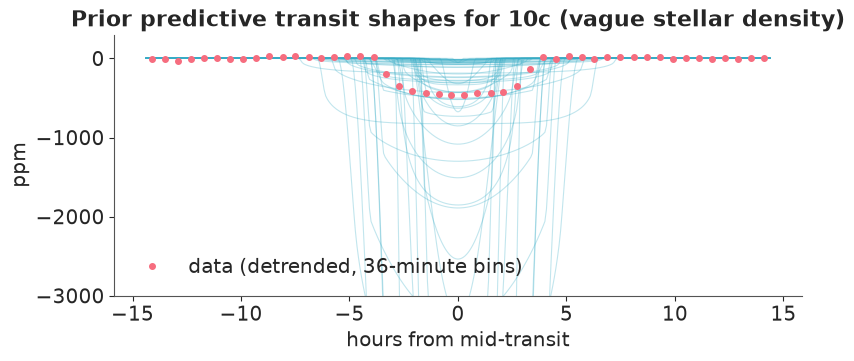

In [15]:
m_c = transit_model(W_c, ["c"], "vague")
with m_c:
    prior_c = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED, var_names=["rho", "k_c", "b_c", "q1", "q2"])
pr = prior_c.prior
tt = np.linspace(-0.6, 0.6, 400)
fig, ax = plt.subplots(figsize=(8, 3.5))
for i in range(60):
    rho_, k_, b_ = (float(pr[v].values.ravel()[i]) for v in ["rho", "k_c", "b_c"])
    q1_, q2_ = float(pr["q1"].values.ravel()[i]), float(pr["q2"].values.ravel()[i])
    aR = (G_CGS * rho_ * (Pc * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    ax.plot(tt * 24, -1e6 * blocked_np(z_of_t(tt, Pc, 0, aR, b_), k_, 2 * np.sqrt(q1_) * q2_,
                                       np.sqrt(q1_) * (1 - 2 * q2_)), color="C0", alpha=0.3, lw=0.8)
ph = fold_phase(t_all, Pc, t0c)
w = np.abs(ph) < 0.6
edges = np.linspace(-0.6, 0.6, 49)
kk = np.digitize(ph[w], edges)
ax.plot(pd.Series(ph[w]).groupby(kk).mean() * 24, pd.Series(resid[w]).groupby(kk).mean(), "o", color="C1",
        ms=4, label="data (detrended, 36-minute bins)")
ax.set(ylim=(-3000, 300), xlabel="hours from mid-transit", ylabel="ppm",
       title="Prior predictive transit shapes for 10c (vague stellar density)")
ax.legend();

The prior allows depths from nothing to several thousand ppm and durations from under an hour to
the whole window: the data will do all the work, which is what we want for this experiment.

In [16]:
def no_ephemeris_jitter(m):
    """Jitter every start value except the period and epoch offsets (see below)."""
    return {v for v in m.free_RVs if not v.name.startswith(("dP_", "dT_"))}


tic = time.time()
with m_c:
    idata_c0 = pm.sample(random_seed=RANDOM_SEED, progressbar=False, initvals={"ub_c": 0.3},
                         compile_kwargs={"jitter_rvs": no_ephemeris_jitter(m_c)})
print(f"sampled in {time.time() - tic:.0f} s (nutpie, {idata_c0.posterior.attrs.get('tuning_steps', '?')} tuning steps)")
summarise(idata_c0, ["rho", "k_c", "b_c", "q1", "q2", "P_c", "T0_c", "log_sigma"])

sampled in 18 s (nutpie, 400 tuning steps)
divergences 12, mean tree depth 4.0, max r_hat 1.181, min bulk ESS 17


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
rho,1.015825,0.257491,0.436185,1.275272,16.605651,1.181451
k_c,0.020547,0.000580,0.019940,0.021615,19.375877,1.147783
b_c,0.316398,0.204772,0.033774,0.715874,17.203572,1.179413
q1,0.372030,0.176259,0.135637,0.708663,779.194388,1.015815
q2,0.334961,0.222371,0.055547,0.768613,527.991134,1.007188
P_c,45.294258,0.000070,45.294142,45.294368,1135.030351,1.003402
T0_c,863.386118,0.000664,863.385063,863.387159,819.190306,1.006200
log_sigma,4.234909,0.019756,4.203450,4.266764,1781.992846,1.002454


**This fit has not converged**: a dozen divergences, $\hat R$ of 1.18 and bulk ESS below 20 for the
density, $b$ and $k$ (nutpie, default settings). The trace of what went wrong is in the geometry. The transit
duration pins down a *combination* of the orbit size and the chord length: a dense star (a small
orbit in stellar radii, a fast planet) with a central transit gives the same duration as a less dense
star with a higher $b$. In the $(\log\rho_\star, b)$ coordinates we sampled, the posterior is a thin
curved ridge whose width changes along its length, and a single NUTS step size cannot suit all of it.

**Fix: parameterise by what the data measure.** Write the model in terms of the transit duration
$D$ (log-uniform between 1 and 24 hours) and $b$, and *derive* the density,
$a/R_\star = \frac{P}{\pi D}\sqrt{(1+k)^2 - b^2}$, $\rho_\star = 3\pi (a/R_\star)^3/(G P^2)$. The
duration is sharply determined, so the remaining freedom is along $b$ alone. We also raise
`target_accept` to 0.95 for the curvature that remains. (The implied prior on the density is not
the same as before - log-uniform in duration rather than in density - but both are vague on the scale
of the posterior.)

In [17]:
m_c = transit_model(W_c, ["c"], "duration")
tic = time.time()
with m_c:
    idata_c = pm.sample(random_seed=RANDOM_SEED, progressbar=False, initvals={"ub_c": 0.3}, target_accept=0.95,
                        compile_kwargs={"jitter_rvs": no_ephemeris_jitter(m_c)})
print(f"sampled in {time.time() - tic:.0f} s")
summarise(idata_c, ["rho", "k_c", "b_c", "q1", "q2", "P_c", "T0_c", "log_sigma"])

sampled in 13 s
divergences 0, mean tree depth 4.5, max r_hat 1.011, min bulk ESS 594


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
rho,0.831224,0.343154,0.262435,1.264442,618.046910,1.009277
k_c,0.020955,0.000848,0.020038,0.022657,593.851459,1.011109
b_c,0.448239,0.246111,0.056763,0.808838,615.370290,1.009998
q1,0.349930,0.156074,0.150587,0.652210,951.387550,1.003589
q2,0.365396,0.239873,0.049666,0.817818,1039.263671,1.002161
P_c,45.294256,0.000070,45.294142,45.294366,4338.519371,1.000016
T0_c,863.386132,0.000660,863.385083,863.387211,4311.703291,1.000169
log_sigma,4.234548,0.019640,4.203566,4.266415,4336.403854,0.999534


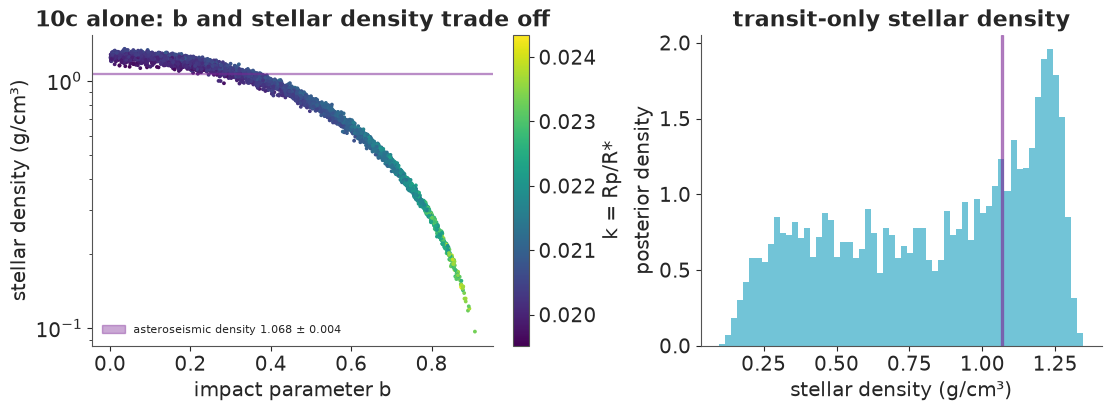

In [18]:
pc = az.extract(idata_c, var_names=["rho", "b_c", "k_c"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sc = axes[0].scatter(pc["b_c"], pc["rho"], c=pc["k_c"], s=3, cmap="viridis")
axes[0].axhspan(1.064, 1.072, color="C3", alpha=0.4, label="asteroseismic density 1.068 ± 0.004")
axes[0].set(xlabel="impact parameter b", ylabel="stellar density (g/cm³)", yscale="log",
            title="10c alone: b and stellar density trade off")
axes[0].legend(loc="lower left", fontsize=8)
plt.colorbar(sc, ax=axes[0], label="k = Rp/R*")
axes[1].hist(pc["rho"], bins=60, color="C0", alpha=0.7, density=True)
axes[1].axvspan(1.064, 1.072, color="C3", alpha=0.5)
axes[1].set(xlabel="stellar density (g/cm³)", ylabel="posterior density", title="transit-only stellar density");

Now the diagnostics are clean (no divergences, $\hat R \le 1.011$, bulk ESS above 500), and the
picture shows the **impact parameter - stellar density
degeneracy** itself: a long curved band from dense stars with central transits to less dense stars
with $b$ up to about 0.9. In principle the ingress and egress shapes break the tie, but with 29.4-minute
cadence and a ten-minute ingress they are barely resolved. Higher $b$ also means a more
limb-darkened chord, so $k$ rises with $b$ (the colour). This is not a computational problem any
more; it is what 26 transits at long cadence can say. The transit-only density does include the
asteroseismic value - a useful consistency check: a strong disagreement would point to an eccentric
orbit, the wrong host star, or a blend.

**The rest of the fix is information from elsewhere.** Kepler-10 is bright enough that Kepler also
recorded its oscillations at 1-minute cadence; the frequencies of those sound waves measure the mean
density directly. Fogtmann-Schulz et al. (2014) give $\rho_\star = 1.068 \pm 0.004$ g/cm³ (the value
listed by the NASA Exoplanet Archive). With that prior, and both planets fitted jointly - plus the
odd/even and occultation terms Part D needs - the geometry is determined.

In [19]:
print(pd.read_csv(data.path("kepler10_archive")).query("pl_refname == 'Fogtmann-Schulz et al. 2014'")
      [["pl_name", "st_dens", "st_denserr1", "st_rad", "st_raderr1", "st_mass"]].head(1).to_string(index=False))
m_bc = transit_model(W_bc, ["b", "c"], (1.068, 0.004),
                     b={"odd_even": True, "occultation": True}, c={"odd_even": True})
tic = time.time()
with m_bc:
    idata_bc = pm.sample(random_seed=RANDOM_SEED, progressbar=False, initvals={"ub_b": 0.3, "ub_c": 0.3},
                         compile_kwargs={"jitter_rvs": set()})
print(f"sampled in {time.time() - tic:.0f} s")
names_bc = ["rho", "q1", "q2", "P_b", "T0_b", "k_b", "b_b", "P_c", "T0_c", "k_c", "b_c", "eps_b", "eps_c",
            "occ_b", "log_sigma"]
summarise(idata_bc, names_bc)

    pl_name  st_dens  st_denserr1  st_rad  st_raderr1  st_mass
Kepler-10 b    1.068        0.004   1.065       0.009    0.913


sampled in 131 s
divergences 0, mean tree depth 3.5, max r_hat 1.009, min bulk ESS 413


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
rho,1.068168,0.004033,1.061621,1.074596,5089.746914,1.005721
q1,0.507765,0.150319,0.290775,0.771509,412.628201,1.008509
q2,0.283687,0.119785,0.125546,0.483364,463.669840,1.006947
P_b,0.837491,0.000000,0.837491,0.837492,5615.912155,0.999735
T0_b,856.004590,0.000136,856.004368,856.004799,3473.017108,1.001761
k_b,0.012634,0.000112,0.012465,0.012820,492.297630,1.007509
b_b,0.354900,0.022993,0.321186,0.394569,585.316715,1.005581
P_c,45.294319,0.000050,45.294241,45.294396,4282.470151,1.004209
T0_c,863.386476,0.000462,863.385752,863.387221,5290.884451,1.000882
k_c,0.020217,0.000173,0.019946,0.020497,581.395919,1.007564


All chains start at the same point (the search result, with the start jitter switched off: a random
jitter of the period offset by one prior unit would put the transits 25-45 minutes off at the ends of
the baseline - a large fraction of 10b's 1.8-hour transit - and chains can get lost there). Convergence diagnostics are fine. The impact parameters are now tied down, and the
radius ratios are precise to about 1%.

### Posterior predictive: the folded transits

10b: max |binned residual| 10.9 ppm, chi2/bin 1.34, width of the 90% band at mid-transit 4.6 ppm
10c: max |binned residual| 59.9 ppm, chi2/bin 1.42, width of the 90% band at mid-transit 15.9 ppm


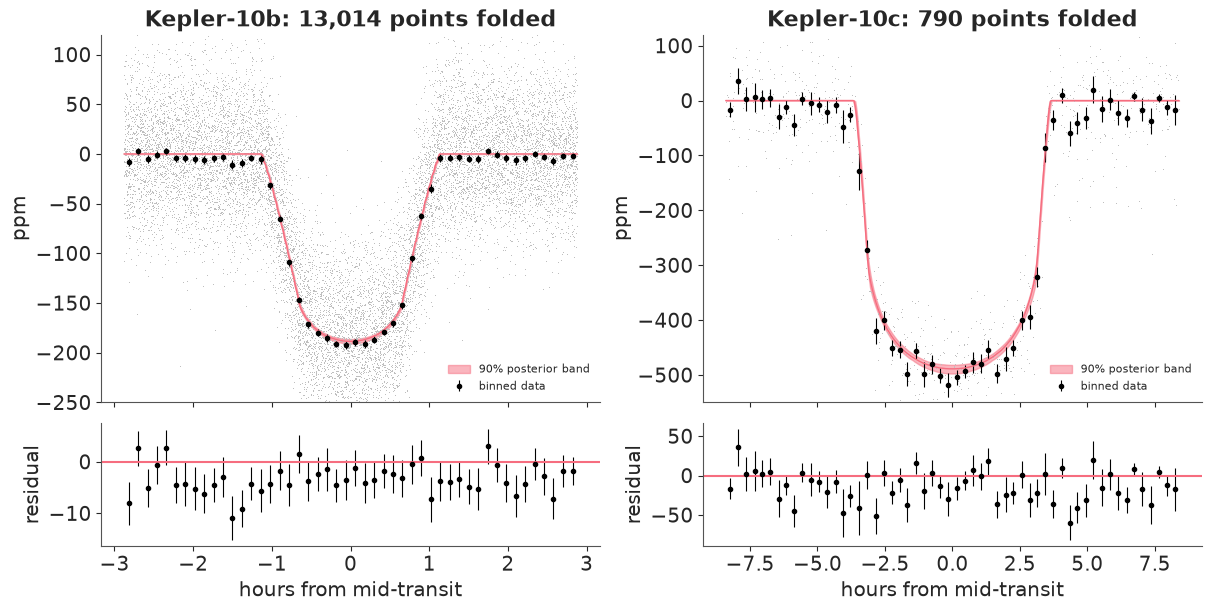

In [20]:
pb = az.extract(idata_bc, num_samples=200, random_seed=RANDOM_SEED)


def model_curve(name, draw, tt, supersample=True):
    rho_, q1_, q2_ = (float(draw[v]) for v in ["rho", "q1", "q2"])
    P_, k_, b_ = (float(draw[f"{v}_{name}"]) for v in ["P", "k", "b"])
    aR = (G_CGS * rho_ * (P_ * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    off = offsets(NSUB[name]) if supersample else np.zeros(1)
    z = z_of_t(tt[:, None] + off, P_, 0.0, aR, b_)
    return -1e6 * blocked_np(z, k_, 2 * np.sqrt(q1_) * q2_, np.sqrt(q1_) * (1 - 2 * q2_)).mean(1)


post_med = {v: float(idata_bc.posterior[v].median()) for v in ["rho", "q1", "q2", "P_b", "T0_b", "k_b", "b_b",
                                                              "P_c", "T0_c", "k_c", "b_c"]}


def median_model(t):
    """Posterior-median transit model (both planets) at times t, ppm."""
    out = np.zeros(len(t))
    for name in ["b", "c"]:
        d = {k_: post_med[k_] for k_ in ["rho", "q1", "q2"]} | {f"{v}_{name}": post_med[f"{v}_{name}"] for v in "Pkb"}
        ph_ = fold_phase(t, post_med[f"P_{name}"], post_med[f"T0_{name}"])
        nr = np.abs(ph_) < 0.4
        out[nr] += model_curve(name, d, ph_[nr])
    return out


# for display: the raw flux in each window minus that window's best-fitting baseline (as in the model)
tw_ = W_bc["t"]
base = W_bc["y"] - median_model(tw_)
for a_, b_ in zip(W_bc["starts"], W_bc["ends"]):
    base[a_:b_] = W_bc["Q"][a_:b_] @ (W_bc["Q"][a_:b_].T @ base[a_:b_])
ycorr = W_bc["y"] - base
fig, axes = plt.subplots(2, 2, figsize=(12, 6), gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
for col, (name, span, nb_) in enumerate([("b", 0.12, 48), ("c", 0.35, 56)]):
    ph = fold_phase(tw_, post_med[f"P_{name}"], post_med[f"T0_{name}"])
    w = np.abs(ph) < span
    edges = np.linspace(-span, span, nb_ + 1)
    kk = np.digitize(ph[w], edges)
    g_ = pd.Series(ycorr[w]).groupby(kk)
    xb = pd.Series(ph[w]).groupby(kk).mean().to_numpy()
    yb, eb = g_.mean().to_numpy(), (g_.std() / np.sqrt(g_.size())).to_numpy()
    tt = np.linspace(-span, span, 400)
    curves = np.array([model_curve(name, pb.isel(sample=i), tt) for i in range(pb.sizes["sample"])])
    lo_, med_, hi_ = np.quantile(curves, [0.05, 0.5, 0.95], axis=0)
    ax = axes[0, col]
    ax.plot(ph[w] * 24, ycorr[w], ",", color="0.75")
    ax.errorbar(xb * 24, yb, eb, fmt="o", ms=3, color="k", lw=0.8, label="binned data")
    ax.fill_between(tt * 24, lo_, hi_, color="C1", alpha=0.5, label="90% posterior band")
    ax.plot(tt * 24, med_, color="C1", lw=1)
    ax.set(ylim=(-(250 if name == "b" else 550), 120), ylabel="ppm",
           title=f"Kepler-10{name}: {int(w.sum()):,} points folded")
    ax.legend(fontsize=8, loc="lower right")
    mb = np.interp(xb, tt, med_)
    axes[1, col].errorbar(xb * 24, yb - mb, eb, fmt="o", ms=3, color="k", lw=0.8)
    axes[1, col].axhline(0, color="C1")
    axes[1, col].set(xlabel="hours from mid-transit", ylabel="residual")
    print(f"10{name}: max |binned residual| {np.abs(yb - mb).max():.1f} ppm, chi2/bin {np.mean(((yb - mb) / eb) ** 2):.2f}, "
          f"width of the 90% band at mid-transit {hi_[200] - lo_[200]:.1f} ppm")

The binned data follow the model through ingress, the limb-darkened bottom and egress for both
planets. The 90% band is only 5 ppm wide at mid-transit for 10b and 16 ppm for 10c: with about 1,500
transits of 10b and 26 of 10c, the *shape* is known to a few ppm. Two details in the residual panels:
the scatter is a little larger than the error bars (mean $\chi^2$ per bin 1.3-1.4, see the red-noise
check below), and 10b's residuals sit a few ppm below zero over the whole window. The latter is real
signal: 10b's own light varies with its phase (dimmest when its night side faces us, at transit), and a
straight-line baseline over 7.7 hours cannot follow that curvature. We checked that quadratic baselines
in every window change $k_b$ by 0.2% and the occultation depth below by 0.1 ppm, well inside the
posterior widths, so we keep the lines.

### Is the noise white?

The likelihood assumes independent errors. A standard check: average the residuals over blocks of
$n$ consecutive cadences; white noise averages down as $1/\sqrt n$, correlated ("red") noise more
slowly. The ratio of the measured to the white-noise expectation, $\beta$, is a common inflation
factor for the parameter uncertainties (Pont, Zucker & Queloz 2006; Winn et al. 2008). We use the
whole light curve, detrended with the 1-day filter (planets masked from it) minus the fitted
transits; the filter removes variations slower than about half a day, so the check is meaningful
up to a few hours - the time scale of the transits.

In [21]:
# display light curve: 1-day filter with both planets masked from its input
use = ~(np.abs(fold_phase(t_all, Pb, t0b)) < 1.5 * durb) & ~(np.abs(fold_phase(t_all, Pc, t0c)) < 1.5 * durc)
flat = y_all - biweight_trend(t_all, y_all, use, 1.0)
ok_ = np.isfinite(flat)
res_flat = (flat - median_model(t_all))[ok_]
t_ok = t_all[ok_]
runs = np.split(np.arange(len(t_ok)), np.flatnonzero(np.diff(t_ok) > 1.5 * CADENCE) + 1)
rows = []
for n in [1, 2, 4, 8, 16, 32]:
    means = np.concatenate([res_flat[r][: len(r) // n * n].reshape(-1, n).mean(1) for r in runs if len(r) >= n])
    rows.append({"bin (cadences)": n, "hours": n * 29.4 / 60, "measured rms": means.std(),
                 "white expectation": res_flat.std() / np.sqrt(n)})
beta_tab = pd.DataFrame(rows)
beta_tab["beta"] = beta_tab["measured rms"] / beta_tab["white expectation"]
print(beta_tab.round(2).to_string(index=False))

 bin (cadences)  hours  measured rms  white expectation  beta
              1   0.49         52.71              52.71  1.00
              2   0.98         40.61              37.27  1.09
              4   1.96         32.01              26.36  1.21
              8   3.92         24.55              18.64  1.32
             16   7.84         17.87              13.18  1.36
             32  15.68         11.57               9.32  1.24


The residuals average down more slowly than white noise: $\beta$ grows from 1.1 at one hour to about
1.3 over four to eight hours - the time scales of the transits. Correlated noise (stellar
granulation, residual instrumental effects) is present, and our white-noise likelihood therefore
understates the uncertainties of transit-shape parameters by very roughly 20-30%. A professional
analysis would model it (a Gaussian process per window) or inflate the errors by $\beta$; we leave
that as an exercise (Try it yourself 2) and read the posterior widths below as somewhat optimistic.

### Sizes, and how they compare

$R_p = k R_\star$ with the asteroseismic stellar radius $R_\star = 1.065 \pm 0.009\,R_\odot$
(Fogtmann-Schulz et al. 2014); we propagate its uncertainty by drawing it independently.

In [22]:
R_SUN_EARTH = 109.076
arch = data.load("kepler10_archive")
rs = rng.normal(1.065, 0.009, size=idata_bc.posterior["k_b"].size)
rows = []
for name in ["b", "c"]:
    k_ = idata_bc.posterior[f"k_{name}"].values.ravel()
    rp = k_ * rs * R_SUN_EARTH
    b_ = idata_bc.posterior[f"b_{name}"].values.ravel()
    P_ = idata_bc.posterior[f"P_{name}"].values.ravel()
    aR = (G_CGS * idata_bc.posterior["rho"].values.ravel() * (P_ * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    t14 = P_ / np.pi * np.arcsin(np.sqrt((1 + k_) ** 2 - b_**2) / aR / np.sin(np.arccos(b_ / aR))) * 24
    rows.append({"planet": f"Kepler-10{name}", "source": "this notebook (median, 90%)",
                 "P (d)": f"{np.median(P_):.7f}", "Rp/R*": f"{np.median(k_):.5f} [{np.quantile(k_, .05):.5f}, {np.quantile(k_, .95):.5f}]",
                 "b": f"{np.median(b_):.2f} [{np.quantile(b_, .05):.2f}, {np.quantile(b_, .95):.2f}]",
                 "T14 (h)": f"{np.median(t14):.2f}",
                 "Rp (Earth)": f"{np.median(rp):.3f} [{np.quantile(rp, .05):.3f}, {np.quantile(rp, .95):.3f}]"})
    for ref in ["Batalha et al. 2011", "Dumusque et al. 2014", "Fogtmann-Schulz et al. 2014",
                "Q1-Q17 DR25 KOI Table", "Bonomo et al. 2025"]:
        a = arch[(arch.pl_name == f"Kepler-10 {name}") & (arch.pl_refname.str.startswith(ref.split(" et")[0]))
                 & (arch.pl_refname.str.contains(ref.split()[-1]))]
        if len(a):
            a = a.iloc[0]
            rows.append({"planet": f"Kepler-10{name}", "source": ref, "P (d)": f"{a.pl_orbper:.7f}",
                         "Rp/R*": f"{a.pl_ratror:.5f}" if np.isfinite(a.pl_ratror) else "",
                         "b": f"{a.pl_imppar:.2f}" if np.isfinite(a.pl_imppar) else "",
                         "T14 (h)": f"{a.pl_trandur:.2f}" if np.isfinite(a.pl_trandur) else "",
                         "Rp (Earth)": f"{a.pl_rade:.3f}" if np.isfinite(a.pl_rade) else ""})
print(pd.DataFrame(rows).to_string(index=False))

    planet                      source      P (d)                      Rp/R*                 b T14 (h)           Rp (Earth)
Kepler-10b this notebook (median, 90%)  0.8374913 0.01263 [0.01246, 0.01282] 0.35 [0.32, 0.40]    1.81 1.467 [1.439, 1.497]
Kepler-10b         Batalha et al. 2011  0.8374950                    0.01232              0.34                        1.416
Kepler-10b        Dumusque et al. 2014  0.8374907                    0.01261              0.31    1.81                1.470
Kepler-10b Fogtmann-Schulz et al. 2014  0.8374912                    0.01254                                          1.460
Kepler-10b       Q1-Q17 DR25 KOI Table  0.8374912                    0.01255              0.02    1.80                1.430
Kepler-10b          Bonomo et al. 2025  0.8374907                                                                     1.470
Kepler-10c this notebook (median, 90%) 45.2943197 0.02022 [0.01993, 0.02051] 0.31 [0.26, 0.34]    6.91 2.349 [2.302, 2.394]
Kepler-1

Our radii - about 1.47 and 2.35 Earth radii - agree with the published solutions to within their
spread (the literature itself moves by several per cent between analyses, mostly through the stellar
radius and the treatment of the impact parameter). The periods agree to better than a second, the
impact parameters sit within the published ranges. Kepler-10b is the smaller: a rocky "super-Earth"
once its mass was measured from the star's reflex motion; 10c is a larger planet on a much wider orbit.

## D. Is it a planet?

Most periodic dips in Kepler data are *not* planets. The classic impostors are **eclipsing binaries**
(two stars eclipsing each other), often diluted by a brighter star in the same pixel so that the dip
looks planet-sized. We turned three of the standard checks into parameters of the model - **model
expansion** rather than separate tests - so their posteriors answer the questions directly:

1. **Odd vs even depths.** Two unequal stars eclipsing each other, found by the search at *half* the
   true period, give alternating deep and shallow dips. $\epsilon$ is the fractional depth difference.
2. **An occultation at phase 0.5.** When the companion passes *behind* the star, its own light
   disappears. For a star the dip is large; for a planet it is ppm-level reflected and thermal light.
3. **V-shaped vs U-shaped.** A grazing eclipse of two stars is V-shaped; the posterior of $b$ tells us
   whether grazing geometries ($b > 1 - k$) are allowed.

For a parameter that is zero under the simple hypothesis, the **Savage-Dickey density ratio** gives
the Bayes factor for "zero" against "free" as the posterior density at zero over the prior density at
zero (for nested models with a shared prior on everything else).

eps_b: posterior mean -0.012, 90% interval [-0.031, +0.006]; Savage-Dickey BF for equal depths 24.6
eps_c: posterior mean -0.001, 90% interval [-0.028, +0.025]; Savage-Dickey BF for equal depths 29.7
occultation depth of 10b: 6.0 ± 0.9 ppm; P(depth > 0) = 1.0000; Savage-Dickey BF for no occultation 1.1e-53


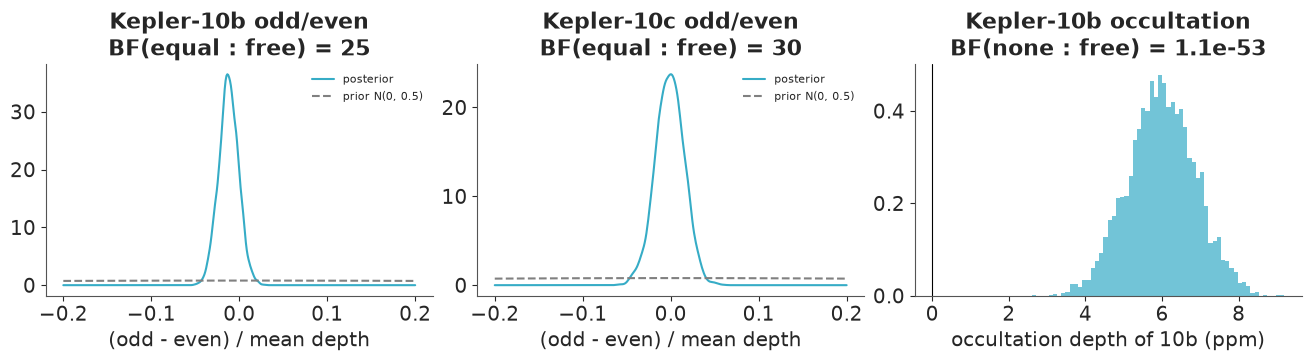

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, v in zip(axes[:2], ["eps_b", "eps_c"]):
    x = idata_bc.posterior[v].values.ravel()
    kde = stats.gaussian_kde(x)
    grid = np.linspace(-0.2, 0.2, 400)
    ax.plot(grid, kde(grid), color="C0", label="posterior")
    ax.plot(grid, stats.norm(0, 0.5).pdf(grid), color="0.5", ls="--", label="prior N(0, 0.5)")
    bf = kde(0.0)[0] / stats.norm(0, 0.5).pdf(0.0)
    ax.set(xlabel="(odd - even) / mean depth", title=f"Kepler-10{v[-1]} odd/even\nBF(equal : free) = {bf:.0f}")
    ax.legend(fontsize=8)
    print(f"{v}: posterior mean {x.mean():+.3f}, 90% interval [{np.quantile(x, .05):+.3f}, {np.quantile(x, .95):+.3f}]; "
          f"Savage-Dickey BF for equal depths {bf:.1f}")
occ = idata_bc.posterior["occ_b"].values.ravel()
axes[2].hist(occ, bins=60, density=True, color="C0", alpha=0.7)
axes[2].axvline(0, color="k", lw=0.8)
bf_occ = stats.gaussian_kde(occ)(0.0)[0] / stats.norm(0, 50).pdf(0.0)
axes[2].set(xlabel="occultation depth of 10b (ppm)", title=f"Kepler-10b occultation\nBF(none : free) = {bf_occ:.1e}")
print(f"occultation depth of 10b: {occ.mean():.1f} ± {occ.std():.1f} ppm; P(depth > 0) = {np.mean(occ > 0):.4f}; "
      f"Savage-Dickey BF for no occultation {bf_occ:.1e}")

* **Odd and even transits have the same depth**: the 90% intervals of the fractional difference,
  -3.1% to +0.6% for 10b and -2.8% to +2.5% for 10c, include zero, and the Savage-Dickey ratios
  favour "equal" (they are large only because the data make the difference so
  much narrower than the N(0, 0.5) prior - a Savage-Dickey Bayes factor always depends on the prior
  width, so read it as "the data are compatible with no difference", not as a precise number).
* **Kepler-10b has an occultation, about 6 ppm deep.** The posterior excludes zero, and the
  Savage-Dickey ratio is tiny. That sounds like the signature of an eclipsing binary - but the *size*
  is the point: a stellar companion hidden behind the star would take away hundreds or thousands of
  ppm. Six ppm is the light of a small, extremely hot planet. The posterior agrees with the
  5.8 ± 2.5 ppm of the discovery paper (Batalha et al. 2011), from eight months of data rather than
  four years. If all of it were reflected light, the planet's geometric albedo $A_g = \delta_\text{occ}
  (a/R_\star)^2 / k^2$ would be:

In [24]:
aR_b = (G_CGS * idata_bc.posterior["rho"].values.ravel() * (idata_bc.posterior["P_b"].values.ravel() * 86400) ** 2
        / (3 * np.pi)) ** (1 / 3)
Ag = occ * 1e-6 * aR_b**2 / idata_bc.posterior["k_b"].values.ravel() ** 2
print(f"geometric albedo if purely reflected: {np.median(Ag):.2f} (90% {np.quantile(Ag, .05):.2f} to {np.quantile(Ag, .95):.2f})")
for name in ["b", "c"]:
    for lbl, idt in [("vague density", idata_c if name == "c" else None), ("asteroseismic", idata_bc)]:
        if idt is None:
            continue
        bb = idt.posterior[f"b_{name}"].values.ravel()
        kk_ = idt.posterior[f"k_{name}"].values.ravel()
        print(f"Kepler-10{name} ({lbl} prior): P(grazing, b > 1 - k) = {np.mean(bb > 1 - kk_):.4f}")

geometric albedo if purely reflected: 0.44 (90% 0.33 to 0.54)
Kepler-10b (asteroseismic prior): P(grazing, b > 1 - k) = 0.0000
Kepler-10c (vague density prior): P(grazing, b > 1 - k) = 0.0000
Kepler-10c (asteroseismic prior): P(grazing, b > 1 - k) = 0.0000


1-day-detrended flux near transit (night side facing us): -6.6 ± 0.6 ppm
1-day-detrended flux near occultation (day side facing us): +1.2 ± 0.6 ppm


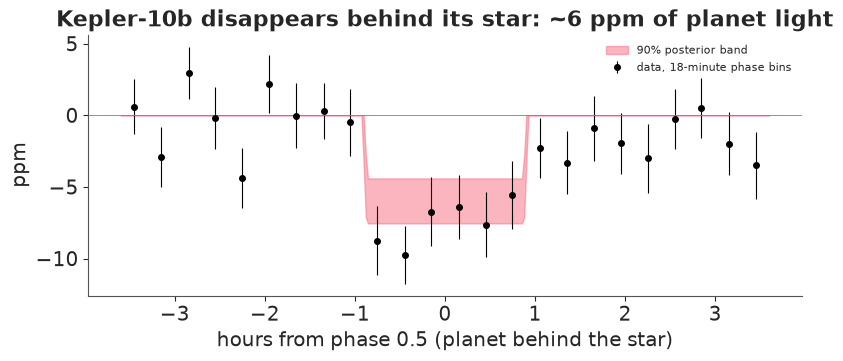

In [25]:
# the occultation, folded: data binned in phase, with the posterior model band
P_med, T_med = post_med["P_b"], post_med["T0_b"]
ph = fold_phase(tw_, P_med, T_med + P_med / 2)
w = np.abs(ph) < 0.15
edges = np.linspace(-0.15, 0.15, 25)
kk = np.digitize(ph[w], edges)
g_ = pd.Series(ycorr[w]).groupby(kk)
xb, yb, eb = pd.Series(ph[w]).groupby(kk).mean(), g_.mean(), g_.std() / np.sqrt(g_.size())
tt = np.linspace(-0.15, 0.15, 300)
curves = []
for i in range(pb.sizes["sample"]):
    d = pb.isel(sample=i)
    aR = (G_CGS * float(d["rho"]) * (float(d["P_b"]) * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    ph2 = 2 * np.pi * tt / float(d["P_b"])
    z = np.sqrt(aR**2 * np.sin(ph2) ** 2 + float(d["b_b"]) ** 2 * np.cos(ph2) ** 2)
    curves.append(-float(d["occ_b"]) * uniform_overlap(z, float(d["k_b"])) / float(d["k_b"]) ** 2)
lo_, hi_ = np.quantile(curves, [0.05, 0.95], axis=0)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.errorbar(xb * 24, yb, eb, fmt="o", color="k", ms=4, lw=0.8, label="data, 18-minute phase bins")
ax.fill_between(tt * 24, lo_, hi_, color="C1", alpha=0.5, label="90% posterior band")
ax.axhline(0, color="0.5", lw=0.6)
ax.set(xlabel="hours from phase 0.5 (planet behind the star)", ylabel="ppm",
       title="Kepler-10b disappears behind its star: ~6 ppm of planet light")
ax.legend(fontsize=8)
# the same light curve detrended with the 1-day filter: mean flux just outside transit and just outside occultation
ph0 = np.abs(fold_phase(t_all, P_med, T_med))
near_tr = (ph0 > 0.06) & (ph0 < 0.16)
near_oc = (np.abs(ph0 - P_med / 2) > 0.06) & (np.abs(ph0 - P_med / 2) < 0.16)
for lbl, m_ in [("near transit (night side facing us)", near_tr), ("near occultation (day side facing us)", near_oc)]:
    v = flat[m_ & np.isfinite(flat)]
    print(f"1-day-detrended flux {lbl}: {v.mean():+.1f} ± {v.std() / np.sqrt(len(v)):.1f} ppm")

An albedo that high is implausible for bare rock. The discovery paper met the same puzzle (their
5.8 ppm implied an albedo of 0.61) and argued that the dayside's *thermal* emission contributes in
Kepler's optical band (its equilibrium temperature is about 1,800 K, and hotter at the substellar
point); Rouan et al. (2011) modelled it as a "lava-ocean" planet with both reflected and emitted light.
The occultation depth alone cannot separate the two. The binned occultation is noisy (error bars of
about 2 ppm per bin) but the flat-bottomed dip is visible.

The two printed numbers show the **phase curve** directly: in the light curve detrended with the 1-day
filter, the flux just outside transit is about 8 ppm *below* its level just outside occultation - the
planet's night side faces us at transit, its day side just before and after occultation. (The two
offsets are not symmetric about zero because the filter's own level is pulled up by masking the
transits; the difference is what matters, and it is consistent with the 7.6 ± 2.0 ppm phase
modulation reported by Batalha et al. 2011.) This is also the extra repeating signal search 3 found at 10b's period.

* **Not grazing.** With the asteroseismic density, grazing geometries have essentially no posterior
  mass for either planet; with the vague prior, 10c's posterior does reach high $b$ but not the
  grazing region (see the probabilities above).

These checks are necessary, not sufficient. The strongest evidence for Kepler-10b was the star's
reflex motion measured with the Keck telescope (Batalha et al. 2011); 10c was validated statistically
and later weighed with radial velocities (Dumusque et al. 2014). Professional vetting also checks
that the dip does not move the star's image on the detector (a background binary) - which needs the
pixel data, not the light curve.

## E. What could we have missed? Injection and recovery

Search 3 found nothing. Does that mean Kepler-10 has no other transiting planets? Only down to the
sensitivity of *our* pipeline. The honest way to measure that sensitivity is to **inject** synthetic
transits into the real light curve (with the two known planets removed), run the same detrending
and search, and record which are recovered. We inject 1,000 planets with periods from 1 to 100 days
and radii from 0.4 to 3 Earth radii (log-uniform), random impact parameters below 0.9 and random
phases, using our transit model with the fitted limb darkening and the asteroseismic density.

To keep the run time reasonable, each injection is searched only within ±0.2% of its true period
(from about 600 trial periods at 1 day to about 80 at 100 days). A signal counts as **recovered** if the best box there beats the 1%
false-alarm threshold from Part B (which was calibrated on the *full* 300,000-period search) and
lands within half a duration of the injected transit times. The local search slightly flatters the
pipeline (no competition from noise peaks elsewhere), but the threshold does not.

In [26]:
q1m, q2m = float(idata_bc.posterior["q1"].median()), float(idata_bc.posterior["q2"].median())
U1, U2 = 2 * np.sqrt(q1m) * q2m, np.sqrt(q1m) * (1 - 2 * q2m)
masked = (np.abs(fold_phase(t_all, post_med["P_b"], post_med["T0_b"])) < 1.5 * durb) | \
         (np.abs(fold_phase(t_all, post_med["P_c"], post_med["T0_c"])) < 1.5 * durc)
t_inj, y_base = t_all[~masked], y_all[~masked]
EARTH_TO_K = 1 / (1.065 * R_SUN_EARTH)


def injected_signal(t, P, t0, rp_earth, b, rho=1.068):
    """Transit signal in ppm (negative), supersampled, computed only near transits."""
    k = rp_earth * EARTH_TO_K
    aR = (G_CGS * rho * (P * 86400) ** 2 / (3 * np.pi)) ** (1 / 3)
    s = np.zeros(len(t))
    ph = fold_phase(t, P, t0)
    near = np.abs(ph) < 0.6 * P / (np.pi * aR) * 1.2 + CADENCE
    s[near] = -1e6 * blocked_np(z_of_t(ph[near][:, None] + offsets(5), P, 0.0, aR, b), k, U1, U2).mean(1)
    return s


def local_search(t, r, P):
    per = period_grid(P * 0.998, P * 1.002, t.max() - t.min())
    return run_bls(t, r, per)


N_INJ = 1000
inj = pd.DataFrame({"P": np.exp(rng.uniform(np.log(1), np.log(100), N_INJ)),
                    "rp": np.exp(rng.uniform(np.log(0.4), np.log(3.0), N_INJ)),
                    "b": rng.uniform(0, 0.9, N_INJ)})
inj["t0"] = t_inj.min() + rng.uniform(0, 1, N_INJ) * inj.P
tic = time.time()
out = []
use_all = np.ones(len(t_inj), bool)
for row in inj.itertuples():
    s = injected_signal(t_inj, row.P, row.t0, row.rp, row.b)
    y_i = y_base + s
    r_i = y_i - biweight_trend(t_inj, y_i, use_all, 1.0)
    res = local_search(t_inj, r_i, row.P)
    best = res.loc[res.snr.idxmax()]
    dt = abs(fold_phase(best.t0, row.P, row.t0))
    dur = max(best.dur, 2 * CADENCE)
    out.append({"snr_found": best.snr, "snr_expected": np.sqrt(np.sum(s**2)) / SIG,
                "found": bool((best.snr > SNR_THR) & (dt < 0.5 * dur + CADENCE))})
inj = pd.concat([inj, pd.DataFrame(out)], axis=1)
print(f"{N_INJ} injections searched in {time.time() - tic:.0f} s; recovered {inj.found.mean():.0%}")

1000 injections searched in 24 s; recovered 82%


The natural predictor of recovery is the **expected SNR** of the injected signal - the square root
of the sum of its squared ppm values over the noise sd, which folds in depth, duration and number of
transits. Recovery as a function of it should be a sigmoid that rises from 0 to (nearly) 1 around the
threshold. We model it as a logistic in $\log \text{SNR}_\text{exp}$ with a ceiling $c$ (a signal can
be lost in gaps or to the detrending even when strong):

$$\Pr(\text{found}) = \frac{c}{1 + \exp\{-(\log \text{SNR}_\text{exp} - \log m)/s\}}.$$

In [27]:
with pm.Model() as eff_model:
    c = pm.Beta("c", 8, 1)
    log_m = pm.Normal("log_m", np.log(SNR_THR), 0.5)
    s_ = pm.HalfNormal("s", 0.5)
    p = c * pm.math.sigmoid((np.log(inj.snr_expected.to_numpy()) - log_m) / s_)
    pm.Bernoulli("found", p=p, observed=inj.found.to_numpy().astype(int))
    idata_eff = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
summarise(idata_eff, ["c", "log_m", "s"])

divergences 0, mean tree depth 2.6, max r_hat 1.001, min bulk ESS 2385


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
c,0.998703,0.001293,0.996235,0.999918,2384.987190,1.000225
log_m,2.303109,0.019151,2.272660,2.333815,4027.087288,1.000175
s,0.075070,0.010440,0.059482,0.093042,3665.380120,1.000758


50% recovery at SNR 10.0; ceiling c = 0.999


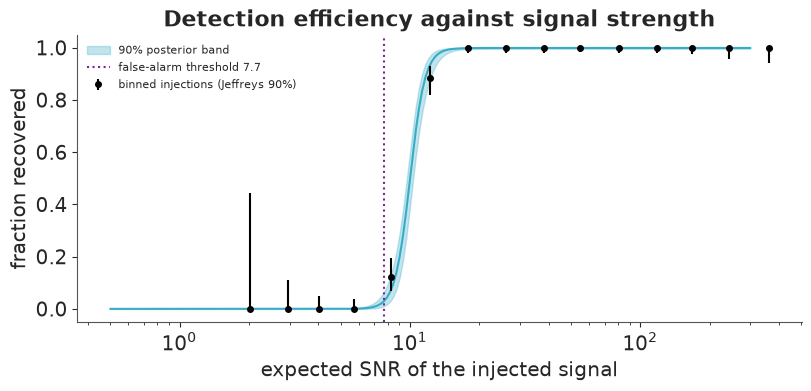

In [28]:
pe = az.extract(idata_eff, var_names=["c", "log_m", "s"])
cs_, lm_, ss_ = pe["c"].values, pe["log_m"].values, pe["s"].values
grid = np.exp(np.linspace(np.log(0.5), np.log(300), 200))
curve = cs_[:, None] / (1 + np.exp(-(np.log(grid)[None] - lm_[:, None]) / ss_[:, None]))
edges = np.exp(np.linspace(np.log(0.5), np.log(300), 18))
kk = np.digitize(inj.snr_expected, edges)
grp = inj.groupby(kk).agg(x=("snr_expected", lambda v: np.exp(np.log(v).mean())), k=("found", "sum"), n=("found", "size"))
lo_b, hi_b = stats.beta.ppf([[0.05], [0.95]], grp.k + 0.5, grp.n - grp.k + 0.5)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.fill_between(grid, *np.quantile(curve, [0.05, 0.95], axis=0), color="C0", alpha=0.3, label="90% posterior band")
ax.plot(grid, np.median(curve, 0), color="C0")
frac = grp.k / grp.n
ax.errorbar(grp.x, frac, [np.clip(frac - lo_b, 0, None), np.clip(hi_b - frac, 0, None)], fmt="o", color="k", ms=4,
            label="binned injections (Jeffreys 90%)")
ax.axvline(SNR_THR, color="C3", ls=":", label=f"false-alarm threshold {SNR_THR:.1f}")
ax.set(xscale="log", xlabel="expected SNR of the injected signal", ylabel="fraction recovered",
       title="Detection efficiency against signal strength")
ax.legend(fontsize=8)
print(f"50% recovery at SNR {np.exp(np.median(lm_)):.1f}; ceiling c = {np.median(cs_):.3f}");

The binned recoveries follow the fitted curve (a posterior predictive check in the form that
matters here). Recovery reaches 50% at an expected SNR of 10, somewhat above the false-alarm
threshold of 7.7: an injected signal loses some of its SNR to the detrending and to the mismatch
between a box and a rounded transit. Above SNR ~13 essentially everything is found.

### From SNR to planets: the efficiency map

To turn this into "which planets could we have found", compute the expected SNR of a 1-Earth-radius
planet at each period, averaged over impact parameters and phases (the transit signal scales as
$R_p^2$, so other radii follow), push it through the posterior efficiency curve, and average.

P =  10 d: 50% detection radius 0.57 Earth radii
P =  50 d: 50% detection radius 0.74 Earth radii
P = 100 d: 50% detection radius 0.87 Earth radii


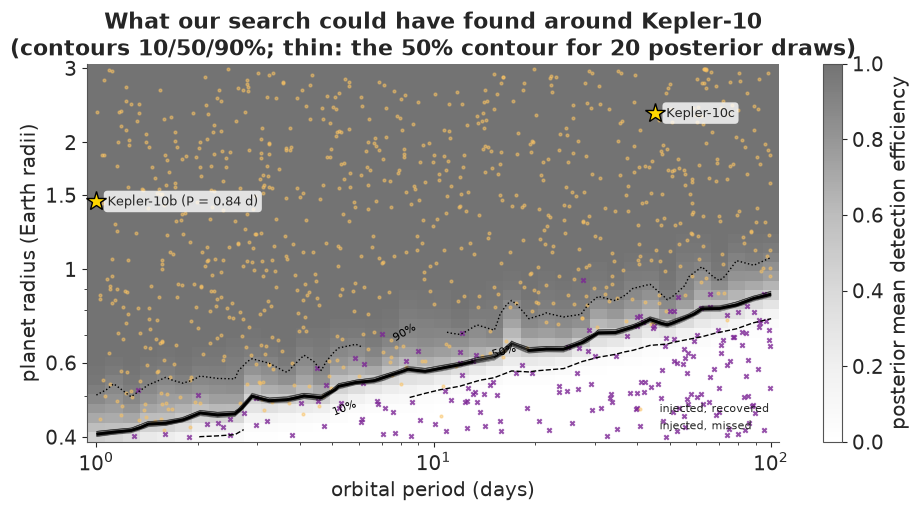

In [29]:
Pg = np.exp(np.linspace(np.log(1), np.log(100), 40))
Rg = np.exp(np.linspace(np.log(0.4), np.log(3.0), 40))
N_DRAW = 40
snr_ref = np.zeros((len(Pg), N_DRAW))
for i, P in enumerate(Pg):
    for j in range(N_DRAW):
        s = injected_signal(t_inj, P, t_inj.min() + rng.uniform() * P, 1.0, rng.uniform(0, 0.9))
        snr_ref[i, j] = np.sqrt(np.sum(s**2)) / SIG
snr = snr_ref[:, None, :] * (Rg[None, :, None] ** 2)                      # (P, R, draws)
sub = rng.choice(len(cs_), 200, replace=False)
eff = np.stack([np.mean(cs_[d] / (1 + np.exp(-(np.log(snr) - lm_[d]) / ss_[d])), axis=-1) for d in sub])
eff_mean = eff.mean(0)
fig, ax = plt.subplots(figsize=(9, 5))
pcm = ax.pcolormesh(Pg, Rg, eff_mean.T, cmap="Greys", vmin=0, vmax=1.6, shading="auto")
cb = plt.colorbar(pcm, ax=ax, label="posterior mean detection efficiency")
cb.ax.set_ylim(0, 1)
for d in range(0, 200, 10):
    ax.contour(Pg, Rg, eff[d].T, levels=[0.5], colors="k", linewidths=0.4, alpha=0.5)
cs = ax.contour(Pg, Rg, eff_mean.T, levels=[0.1, 0.5, 0.9], colors="k", linewidths=[1, 2, 1], linestyles=["--", "-", ":"])
ax.clabel(cs, fmt=lambda v: f"{v:.0%}", fontsize=8)
ax.scatter(inj.P[inj.found], inj.rp[inj.found], s=4, color="C2", alpha=0.5, label="injected, recovered")
ax.scatter(inj.P[~inj.found], inj.rp[~inj.found], s=10, marker="x", color="C3", alpha=0.8, label="injected, missed")
for name, rp in [("b", 1.45), ("c", 2.35)]:
    ax.plot(max(post_med[f"P_{name}"], 1.0), rp, "*", ms=15, color="gold", mec="k", clip_on=False, zorder=5)
    ax.annotate(f"Kepler-10{name}" + (" (P = 0.84 d)" if name == "b" else ""), (max(post_med[f"P_{name}"], 1.0), rp),
                xytext=(8, -3), textcoords="offset points", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.8))
ax.set(xscale="log", yscale="log", xlabel="orbital period (days)", ylabel="planet radius (Earth radii)",
       title="What our search could have found around Kepler-10\n(contours 10/50/90%; thin: the 50% contour for 20 posterior draws)")
ax.set_yticks([0.4, 0.6, 1, 1.5, 2, 3], ["0.4", "0.6", "1", "1.5", "2", "3"])
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
for P in [10, 50, 100]:
    i = np.argmin(np.abs(Pg - P))
    r50 = np.exp(np.interp(0.5, eff_mean[i], np.log(Rg)))
    print(f"P = {P:3d} d: 50% detection radius {r50:.2f} Earth radii")

The search would find half of all transiting planets of 0.6 Earth radii at 10-day periods, and half
of those of 0.9 Earth radii at 100 days; sensitivity falls slowly with period (fewer transits, each
longer - the SNR falls roughly as $P^{-1/3}$). The 20 posterior draws of the 50% contour lie on top
of each other: 1,000 injections pin the efficiency curve so well that its uncertainty is invisible at
this scale. The jaggedness of the contours is the finite number of impact parameters and phases we
averaged over per period (40), and the transition zone between recovered (dots) and missed (crosses)
injections is the real scatter from where each planet's transits happen to fall relative to the gaps.
Both known planets sit far inside the efficient region. So the empty search 3 says: **no other
transiting planet larger than about 1 Earth radius with a period under 100 days**, at the efficiency
shown. (Kepler-10 does have a third planet, Kepler-10d, found in radial velocities at
about 151 days (Bonomo et al. 2023). It is not known to transit, and would be outside our period
range anyway.)

## F. A visitor from another star: is 2I/Borisov unbound?

Part F leaves the light curves behind. An orbit is determined from **angles**: at each time an
observatory reports the right ascension and declination of the comet against the reference stars.
The distance is never observed. A heliocentric orbit has six parameters (a position and a velocity at
some epoch); the question is whether those positions on the sky are only compatible with **energy
$E = v^2/2 - GM_\odot/r > 0$** - eccentricity $e > 1$.

The data: every optical observation the Minor Planet Center holds for 2I from the discovery night
(30 August 2019) to 15 October 2019.

In [30]:
data.describe("borisov_astrometry")
obs = data.load("borisov_astrometry")
codes = data.load("borisov_obscodes").set_index("stn")
hz = data.load("borisov_horizons")
sbdb = data.load("borisov_sbdb").set_index("element")
t_utc = pd.to_datetime(obs.obstime, format="ISO8601", utc=True)
obs["jd_utc"] = (t_utc - pd.Timestamp("2000-01-01T12:00", tz="UTC")).dt.total_seconds().to_numpy() / 86400 + 2451545.0
obs["jd_tdb"] = obs.jd_utc + 69.184 / 86400        # TT - UTC in 2019 (37 leap seconds + 32.184 s); TDB - TT < 2 ms
obs["day"] = obs.jd_utc - obs.jd_utc.min()
print(f"{len(obs):,} positions from {obs.stn.nunique()} observatories; "
      f"{obs.rmsra.notna().mean():.0%} report an uncertainty; satellite NEOSSat (C53): {int((obs.stn == 'C53').sum())} positions")
print(obs.groupby(obs.day.astype(int) // 7 * 7).size().rename("positions per week (starting day)").to_string())

borisov_astrometry: 1,513 optical positions from discovery (2019-08-30) to 2019-10-15 UTC, deprecated rows removed, from 88 observatories: obstime (ISO UTC), ra, dec (degrees, ICRF, as reported), stn (MPC observatory code), mag, band, astcat (reference star catalogue), rmsra, rmsdec (arcsec, where reported), mode, notes, and for the satellite NEOSSat (C53) its geocentric position: sys (ICRF_KM), pos1-pos3 (km).
  source: IAU Minor Planet Center observations API (ADES fields), object 2I/Borisov (C/2019 Q4). MPC data are public; the MPC asks for the acknowledgement 'This research has made use of data and/or services provided by the International Astronomical Union's Minor Planet Center.' BUILT by tools/build_e78_exoplanets.py (a POST-style JSON request) - keep the cached file.
  url:    https://data.minorplanetcenter.net/api/get-obs
1,513 positions from 88 observatories; 27% report an uncertainty; satellite NEOSSat (C53): 267 positions
day
0      58
7     179
14    264
21    289
28    37

### From an orbit to a predicted position

The **observation model** turns a state vector into what an observer sees:

1. **Integrate the orbit** from the epoch. We use a fixed-step 4th-order Runge-Kutta integrator (a
   quarter-day step) in heliocentric coordinates with the Sun and, as perturbers, the Earth-Moon
   system, Jupiter and Saturn at their JPL Horizons positions (the "indirect" terms account for the Sun
   being pulled by the planets). Unlike Kepler's equation, the integrator does not care whether the
   orbit is an ellipse, parabola or hyperbola - which matters when $e$ is the unknown.
2. **Where is the observer?** The Earth's position from Horizons, plus the observatory's position on
   the rotating Earth (MPC parallax constants and the Earth rotation angle), or, for the NEOSSat
   satellite, the geocentric position reported with each observation. At 2 au, the Earth's radius
   subtends 4 arcseconds - ten times the measurement errors - so **parallax** cannot be ignored.
3. **Light time.** We see the comet where it was ~17 minutes earlier: solve $\tau = |x(t - \tau) -
   x_\text{obs}(t)|/c$ by iteration.
4. The unit vector from observer to comet gives the predicted RA and Dec. Residuals are in arcseconds
   ($\Delta\alpha\cos\delta$, $\Delta\delta$).

All of it is written in JAX, so it is differentiable and can be vectorised over thousands of trial
orbits. How good is this dynamical model? We start it from JPL's own state for 2I (their solution
JPL#54, which includes all planets, relativity and non-gravitational forces from the outgassing
comet) and fit our initial state to JPL's positions over the whole 46-day arc.

In [31]:
GM_SUN = 2.9591220828559115e-4                     # au^3 / day^2
GM = {"earth": 8.997011390199871e-10, "jupiter": 2.825345909524226e-7, "saturn": 8.459715185680659e-8}
C_AUD = 173.1446326742403                         # speed of light, au/day
AU_KM = 149597870.7
ARCSEC = np.pi / 180 / 3600
OBLIQ = np.radians(23.4392911)
TAB = {b: g.reset_index(drop=True) for b, g in hz.groupby("body")}


def hermite(tab, t, deriv=False):
    """Cubic Hermite interpolation of a Horizons table (positions and velocities)."""
    tt = tab.jd_tdb.to_numpy()
    X, V = tab[["x", "y", "z"]].to_numpy(), tab[["vx", "vy", "vz"]].to_numpy()
    j = np.clip(np.searchsorted(tt, t) - 1, 0, len(tt) - 2)
    h = (tt[j + 1] - tt[j])[:, None]
    s = (t - tt[j])[:, None] / h
    if deriv:
        return ((6 * s**2 - 6 * s) / h * X[j] + (3 * s**2 - 4 * s + 1) * V[j]
                + (-6 * s**2 + 6 * s) / h * X[j + 1] + (3 * s**2 - 2 * s) * V[j + 1])
    return ((2 * s**3 - 3 * s**2 + 1) * X[j] + (s**3 - 2 * s**2 + s) * h * V[j]
            + (-2 * s**3 + 3 * s**2) * X[j + 1] + (s**3 - s**2) * h * V[j + 1])


# observer positions: Earth + observatory (ground: parallax constants rotated by the Earth rotation angle)
era = 2 * np.pi * (0.7790572732640 + 1.00273781191135448 * (obs.jd_utc.to_numpy() - 2451545.0))
c_ = codes.reindex(obs.stn)
lon = np.radians(c_.longitude.to_numpy(float)) + era
RE_AU = 6378.137 / AU_KM
geo = RE_AU * np.c_[c_.rhocosphi.to_numpy(float) * np.cos(lon), c_.rhocosphi.to_numpy(float) * np.sin(lon),
                    c_.rhosinphi.to_numpy(float)]
sat = (obs.stn == "C53").to_numpy()
geo[sat] = obs.loc[sat, ["pos1", "pos2", "pos3"]].to_numpy(float) / AU_KM
OBS_POS = hermite(TAB["earth"], obs.jd_tdb.to_numpy()) + geo
assert np.isfinite(OBS_POS).all()
RA, DEC = np.radians(obs.ra.to_numpy()), np.radians(obs.dec.to_numpy())


def make_propagator(t_start, t_end, h=0.25):
    n = int(np.ceil((t_end - t_start) / h))
    grid = t_start + h * np.arange(n + 1)
    stages = np.stack([grid[:-1], grid[:-1] + h / 2, grid[:-1] + h], 1).ravel()
    PX = jnp.asarray(np.stack([hermite(TAB[b], stages).reshape(n, 3, 3) for b in GM], 1))  # (n, bodies, 3, 3)
    GMs = jnp.asarray([GM[b] for b in GM])[:, None]

    def acc(r, pp):
        d = pp - r
        return (-GM_SUN * r / jnp.linalg.norm(r) ** 3
                + jnp.sum(GMs * (d / jnp.linalg.norm(d, axis=1, keepdims=True) ** 3
                                 - pp / jnp.linalg.norm(pp, axis=1, keepdims=True) ** 3), 0))

    def step(y, pp):
        r, v = y
        k1r, k1v = v, acc(r, pp[:, 0])
        k2r, k2v = v + h / 2 * k1v, acc(r + h / 2 * k1r, pp[:, 1])
        k3r, k3v = v + h / 2 * k2v, acc(r + h / 2 * k2r, pp[:, 1])
        k4r, k4v = v + h * k3v, acc(r + h * k3r, pp[:, 2])
        new = (r + h / 6 * (k1r + 2 * k2r + 2 * k3r + k4r), v + h / 6 * (k1v + 2 * k2v + 2 * k3v + k4v))
        return new, new

    def propagate(r0, v0):
        _, (R, V) = jax.lax.scan(step, (r0, v0), PX)
        return jnp.concatenate([r0[None], R]), jnp.concatenate([v0[None], V])

    def position_at(R, V, t):
        j = jnp.clip(jnp.floor((t - t_start) / h).astype(int), 0, n - 1)
        s = ((t - t_start) / h - j)[:, None]
        return ((2 * s**3 - 3 * s**2 + 1) * R[j] + (s**3 - 2 * s**2 + s) * h * V[j]
                + (-2 * s**3 + 3 * s**2) * R[j + 1] + (s**3 - s**2) * h * V[j + 1])

    return propagate, position_at


def elements(r, v):
    """Heliocentric osculating elements: e, q (au), v_inf (km/s; NaN if bound), inclination to the ecliptic."""
    rn = np.linalg.norm(r, axis=-1)
    hvec = np.cross(r, v)
    e = np.linalg.norm(np.cross(v, hvec) / GM_SUN - r / rn[..., None], axis=-1)
    energy = (v**2).sum(-1) / 2 - GM_SUN / rn
    q = (np.linalg.norm(hvec, axis=-1) ** 2 / GM_SUN) / (1 + e)
    vinf = np.where(energy > 0, np.sqrt(2 * np.maximum(energy, 0)) * AU_KM / 86400, np.nan)
    h_ecl = hvec[..., 2] * np.cos(OBLIQ) - hvec[..., 1] * np.sin(OBLIQ)
    inc = np.degrees(np.arccos(h_ecl / np.linalg.norm(hvec, axis=-1)))
    return e, q, vinf, inc


# check the dynamics against JPL's trajectory of 2I
from scipy.optimize import least_squares
jpl = TAB["2I_jpl"]
T_EPOCH = obs.jd_tdb.min()
jt0 = int(np.searchsorted(jpl.jd_tdb, T_EPOCH)) - 1
tj = jpl.jd_tdb.to_numpy()[jt0:]
tj = tj[tj <= obs.jd_tdb.max() + 0.25]
Xj = jpl[["x", "y", "z"]].to_numpy()[jt0:jt0 + len(tj)]
dist_j = np.linalg.norm(Xj - hermite(TAB["earth"], tj), axis=1)
prop_j, pos_j = make_propagator(tj[0], tj[-1] + 0.3)
f_j = jax.jit(lambda x: pos_j(*prop_j(x[:3], x[3:]), jnp.asarray(tj)))
sol = least_squares(lambda x: ((np.asarray(f_j(jnp.asarray(x))) - Xj) / dist_j[:, None] / ARCSEC).ravel(),
                    np.r_[Xj[0], jpl[["vx", "vy", "vz"]].to_numpy()[jt0]], x_scale=1e-4)
print(f"our N-body model reproduces JPL's 46-day trajectory of 2I to within "
      f"{np.abs(sol.fun).max():.2f} arcsec (largest coordinate difference seen from the Earth)")
s_jpl = hermite(jpl, np.array([T_EPOCH]))[0], hermite(jpl, np.array([T_EPOCH]), deriv=True)[0]
e_j, q_j, v_j, i_j = (float(x) for x in elements(*s_jpl))
print(f"JPL#54 osculating elements at our epoch: e = {e_j:.4f}, q = {q_j:.4f} au, v_inf = {v_j:.2f} km/s, i = {i_j:.2f} deg")
print(f"(JPL's published elements at epoch JD {float(sbdb.loc['epoch', 'value']):.1f}: e = {float(sbdb.loc['e', 'value']):.4f}, "
      f"q = {float(sbdb.loc['q', 'value']):.4f} au, i = {float(sbdb.loc['i', 'value']):.2f} deg)")

our N-body model reproduces JPL's 46-day trajectory of 2I to within 0.11 arcsec (largest coordinate difference seen from the Earth)
JPL#54 osculating elements at our epoch: e = 3.3566, q = 2.0065 au, v_inf = 32.28 km/s, i = 44.05 deg
(JPL's published elements at epoch JD 2458853.5: e = 3.3565, q = 2.0065 au, i = 44.05 deg)


A difference of about a tenth of an arcsecond - smaller than the measurement errors. It comes from what
we leave out: the comet's own non-gravitational acceleration (gas jets), the other planets, and
relativity. The comparison values
for everything that follows are **JPL's osculating elements at our epoch** (the first observation),
computed from their trajectory; the published elements refer to a later epoch and differ slightly.

### Parameterising the orbit by what the data see

On a short arc the data determine the comet's direction $(\alpha, \delta)$ and its angular motion
$(\dot\alpha\cos\delta, \dot\delta)$ at the epoch very well - four numbers called the **attributable**.
What they cannot see is the geocentric **distance $\rho$ and its rate $\dot\rho$**. So we write the
heliocentric state as

$$\mathbf r = \mathbf R_\oplus + \rho\,\hat{\mathbf u},\qquad
  \mathbf v = \mathbf V_\oplus + \dot\rho\,\hat{\mathbf u} + \rho\,(\dot\alpha\cos\delta\,\hat{\mathbf e}_\alpha
  + \dot\delta\,\hat{\mathbf e}_\delta),$$

and each pair $(\rho, \dot\rho)$ with the best-fitting attributable is a complete orbit with its own
eccentricity. The weakly determined part of the problem is two-dimensional, so we can map it
exhaustively on a grid - the idea behind **statistical ranging** and the "admissible region" used for
new discoveries.

**Noise model.** Where observers report an uncertainty we use it (at least 0.2"), else 0.5". Many
observatories report several positions per night measured against the same reference stars, which
share their errors; as in common practice (Veres et al. 2017), a night with $n > 4$ positions from
one site has each error inflated by $\sqrt{n/4}$. Astrometry has outliers (mis-identifications,
timing errors), so the likelihood is a **Student-t** with $\nu$ degrees of freedom, and an overall
scale factor $s$ on the stated errors - both learned from the full arc below.

In [32]:
sig = np.fmax(np.fmax(obs.rmsra.to_numpy(), obs.rmsdec.to_numpy()), 0.2)
sig = np.where(np.isfinite(sig), sig, 0.5)
night = (obs.jd_utc + codes.reindex(obs.stn).longitude.fillna(0).to_numpy() / 360).astype(int).astype(str) + obs.stn
sig = sig * np.sqrt(np.maximum(night.map(night.value_counts()).to_numpy() / 4, 1))
E0 = hermite(TAB["earth"], np.array([T_EPOCH]))[0]
VE0 = hermite(TAB["earth"], np.array([T_EPOCH]), deriv=True)[0]


def state_from(theta):
    a, d, ad, dd, logr, rd = theta
    u = jnp.array([jnp.cos(d) * jnp.cos(a), jnp.cos(d) * jnp.sin(a), jnp.sin(d)])
    ea = jnp.array([-jnp.sin(a), jnp.cos(a), 0.0])
    ed = jnp.array([-jnp.sin(d) * jnp.cos(a), -jnp.sin(d) * jnp.sin(a), jnp.cos(d)])
    rho = jnp.exp(logr)
    return E0 + rho * u, VE0 + rd * u + rho * (ad * ea + dd * ed)


def make_residuals(n, t_end):
    """Normalised residuals (2 per observation) of the first n observations, times a 0/1 mask over
    them (one compiled function serves every arc)."""
    propagate, position_at = make_propagator(T_EPOCH, t_end + 0.3)
    tob, opos = jnp.asarray(obs.jd_tdb.to_numpy()[:n]), jnp.asarray(OBS_POS[:n])
    ra_, dec_, sig_ = jnp.asarray(RA[:n]), jnp.asarray(DEC[:n]), jnp.asarray(sig[:n])

    def resid(theta, msk):
        R, V = propagate(*state_from(theta))
        x = position_at(R, V, tob)
        for _ in range(2):                                   # light-time iteration
            x = position_at(R, V, tob - jnp.linalg.norm(x - opos, axis=1) / C_AUD)
        rel = x - opos
        pra = jnp.arctan2(rel[:, 1], rel[:, 0])
        pdec = jnp.arcsin(rel[:, 2] / jnp.linalg.norm(rel, axis=1))
        dra = jnp.angle(jnp.exp(1j * (ra_ - pra))) * jnp.cos(dec_)
        return jnp.concatenate([msk, msk]) * jnp.concatenate([dra, dec_ - pdec]) / ARCSEC / jnp.concatenate([sig_, sig_])

    return resid


def loglike_t(r, nu):
    return jnp.sum(jax.scipy.stats.t.logpdf(r, nu))

In [33]:
def attributable_guess():
    s = obs.jd_tdb.to_numpy() <= T_EPOCH + 1.5
    tt_ = obs.jd_tdb.to_numpy()[s] - T_EPOCH
    pa, pd_ = np.polyfit(tt_, np.unwrap(RA[s]), 1), np.polyfit(tt_, DEC[s], 1)
    return np.array([pa[1], pd_[1], pa[0] * np.cos(pd_[1]), pd_[0]])


def make_node_solver(resid, n_iter=10):
    """At fixed (log distance, range rate): best attributable and the Laplace log evidence."""
    def solve(att0, lr, rd, msk, nu):
        r4 = lambda att: resid(jnp.concatenate([att, jnp.array([lr, rd])]), msk)
        att = att0
        for _ in range(n_iter):
            r = r4(att)
            J = jax.jacfwd(r4)(att)
            w = (nu + 1) / (nu + r**2)
            H = J.T @ (J * w[:, None])
            att = att - jnp.linalg.solve(H + 1e-9 * jnp.diag(jnp.diag(H)), J.T @ (w * r))
        r = r4(att)
        J = jax.jacfwd(r4)(att)
        logdet = jnp.linalg.slogdet(J.T @ J * (nu + 1) / (nu + 3))[1]
        return att, loglike_t(r, nu) - 0.5 * logdet + 2 * jnp.log(2 * jnp.pi)
    batched = jax.jit(jax.vmap(solve, in_axes=(None, 0, 0, None, None)))

    def run(att0, lr, rd, msk, nu, chunk=1000):     # chunks keep memory low
        outs = [batched(att0, lr[i:i + chunk], rd[i:i + chunk], msk, nu) for i in range(0, len(lr), chunk)]
        return np.concatenate([np.asarray(o[0]) for o in outs]), np.concatenate([np.asarray(o[1]) for o in outs])
    return run


def orbit_elements_of(att, lr, rd):
    th = np.c_[att, lr, rd]
    st = jax.vmap(state_from)(jnp.asarray(th))
    return elements(np.asarray(st[0]), np.asarray(st[1]))


def make_ridge_solver(resid, n_iter=25):
    """At a fixed distance, optimise the attributable AND the range rate (LM steps); Laplace log
    evidence and the conditional sd of the range rate."""
    def solve(x0, lr, msk, nu):
        f = lambda x: resid(jnp.concatenate([x[:4], jnp.array([lr]), x[4:]]), msk)
        loss = lambda x: -loglike_t(f(x), nu)

        def body(i, c):
            x, lam, cur = c
            r = f(x)
            J = jax.jacfwd(f)(x)
            w = (nu + 1) / (nu + r**2)
            H = J.T @ (J * w[:, None])
            new = x - jnp.linalg.solve(H + lam * jnp.diag(jnp.diag(H)) + 1e-12 * jnp.eye(5), J.T @ (w * r))
            val = loss(new)
            ok = jnp.isfinite(val) & (val < cur)
            return jnp.where(ok, new, x), jnp.where(ok, lam / 3, lam * 4), jnp.where(ok, val, cur)
        x, _, cur = jax.lax.fori_loop(0, n_iter, body, (x0, 1e-3, loss(x0)))
        J = jax.jacfwd(f)(x)
        H = J.T @ J * (nu + 1) / (nu + 3)
        logz = -cur - 0.5 * jnp.linalg.slogdet(H)[1] + 2.5 * jnp.log(2 * jnp.pi)
        return x, logz, jnp.sqrt(jnp.abs(jnp.linalg.inv(H)[4, 4]))
    f = jax.jit(jax.vmap(solve, in_axes=(0, 0, None, None)))
    return lambda x0, lr, msk, nu: tuple(np.asarray(v) for v in f(jnp.asarray(x0), jnp.asarray(lr), msk, nu))


ARCS = [1, 2, 3, 5, 7, 10]
LR, RD = (np.log(0.05), np.log(30.0)), (-0.1, 0.1)
n_max = int(np.sum(obs.jd_tdb.to_numpy() <= T_EPOCH + max(ARCS)))
att0 = jnp.asarray(attributable_guess())
_resid_arcs = make_residuals(n_max, T_EPOCH + max(ARCS))
solver, ridge = make_node_solver(_resid_arcs), make_ridge_solver(_resid_arcs)


def range_arc(arc, scale, nu):
    """Posterior over (log distance, range rate) from the first `arc` days, errors x `scale`."""
    msk = jnp.asarray((obs.jd_tdb.to_numpy()[:n_max] <= T_EPOCH + arc) / scale)
    # (1) coarse grid over the prior box
    g1, g2 = np.linspace(*LR, 60), np.linspace(*RD, 60)
    L1, R1 = np.meshgrid(g1, g2, indexing="ij")
    att1, lz1 = solver(att0, jnp.asarray(L1.ravel()), jnp.asarray(R1.ravel()), msk, nu)
    e1 = orbit_elements_of(att1, L1.ravel(), R1.ravel())[0].reshape(L1.shape)
    lz1 = np.where(np.isfinite(lz1), lz1, -np.inf).reshape(L1.shape)
    # (2) the ridge: range rate optimised at each distance; twice, zooming on the plausible distances
    lr_f = np.linspace(*LR, 300)
    row = np.clip(np.searchsorted(g1, lr_f), 0, len(g1) - 1)
    jb = np.argmax(lz1[row], axis=1)
    x0 = np.c_[att1.reshape(60, 60, 4)[row, jb], g2[jb]]
    for _ in range(2):
        x5, lz5, _sd = ridge(x0, lr_f, msk, nu)
        lz5 = np.where(np.isfinite(lz5), lz5, -np.inf)
        ok = lz5 > lz5.max() - 25
        span = max(np.ptp(lr_f[ok]), 0.02)
        new = np.linspace(max(lr_f[ok].min() - 0.1 * span, LR[0]), min(lr_f[ok].max() + 0.1 * span, LR[1]), 100)
        x0 = x5[np.clip(np.searchsorted(lr_f, new), 0, len(lr_f) - 1)]
        lr_f = new
    x5, lz5, sd5 = ridge(x0, lr_f, msk, nu)
    # (3) sheared grid around the ridge
    lo_r, hi_r = np.clip(x5[:, 4] - 6 * sd5, *RD), np.clip(x5[:, 4] + 6 * sd5, *RD)
    width = np.maximum(hi_r - lo_r, 1e-12)
    Rd = lo_r[:, None] + width[:, None] * np.linspace(0, 1, 41)[None]
    L = np.repeat(lr_f[:, None], 41, 1)
    att, lz = solver(att0, jnp.asarray(L.ravel()), jnp.asarray(Rd.ravel()), msk, nu)
    lz = np.where(np.isfinite(lz), lz, -np.inf).reshape(L.shape) + np.log(width)[:, None]
    w_ = np.exp(lz - lz.max())
    w_ /= w_.sum()
    e_ = orbit_elements_of(att, L.ravel(), Rd.ravel())[0].reshape(L.shape)
    return dict(L=L, Rd=Rd, post=w_, e=e_, att=att, n=int(np.sum(np.asarray(msk) > 0)), L1=L1, R1=R1, e1=e1,
                dens=w_ / (np.gradient(lr_f)[:, None] * width[:, None] / 40),
                prior_hyp=np.mean(e1 > 1), post_hyp=w_[e_ > 1].sum())

### The full 46-day arc in PyMC

With 1,513 positions the posterior is compact, and NUTS can do the work. We wrap the residual
function with `pytensor.wrap_jax`, so PyMC gets values and gradients from JAX. A starting point comes
from a quick ranging pass on the first 10 days (the machinery is explained in the next section),
refined by Levenberg-Marquardt on the whole arc. To make NUTS's job easy we **whiten** the
parameters: with the mode $\hat\theta$ and the inverse Hessian $C = LL^\top$ there, we sample $z$ with
$\theta = \hat\theta + Lz$ (a flat prior on $\theta$ is a flat prior on $z$). The likelihood is
Student-t with $\nu$ and the error scale $s$ learned from the data.

In [34]:
tic = time.time()
_resid_all = make_residuals(len(obs), obs.jd_tdb.max())
ONES = jnp.ones(len(obs))
resid_full = lambda th: _resid_all(th, ONES)
quick = range_arc(10, scale=1.0, nu=4.0)
best = np.argmax(quick["post"])
theta = np.r_[quick["att"][best], quick["L"].ravel()[best], quick["Rd"].ravel()[best]]
r_f, J_f = jax.jit(resid_full), jax.jit(jax.jacfwd(resid_full))
obj = lambda th: -float(loglike_t(r_f(jnp.asarray(th)), 4.0))
cur, lam = obj(theta), 1e-3
for _ in range(40):                                   # Levenberg-Marquardt with Student-t (IRLS) weights
    r = np.asarray(r_f(jnp.asarray(theta)))
    J = np.asarray(J_f(jnp.asarray(theta)))
    w = 5.0 / (4.0 + r**2)
    H, g = J.T @ (J * w[:, None]), J.T @ (w * r)
    while lam < 1e8:
        new = theta - np.linalg.solve(H + lam * np.diag(np.diag(H)), g)
        if obj(new) < cur:
            theta, cur, lam = new, obj(new), lam / 3
            break
        lam *= 5
TH_HAT = theta
Lc = np.linalg.cholesky(np.linalg.inv(np.asarray(jax.hessian(lambda th: -loglike_t(resid_full(th), 4.0))(jnp.asarray(TH_HAT)))))


@wrap_jax
def resid_white(z):
    return resid_full(jnp.asarray(TH_HAT) + jnp.asarray(Lc) @ z)


with pm.Model() as orbit_model:
    z = pm.Flat("z", shape=6)
    pm.Deterministic("theta", pt.as_tensor(TH_HAT) + pt.as_tensor(Lc) @ z)
    log_s = pm.Normal("log_s", 0.0, 0.5)
    nu = pm.Gamma("nu", 2.0, 0.1)
    r = pt.specify_shape(resid_white(pt.specify_shape(z, (6,))), (2 * len(obs),))
    pm.Potential("likelihood", pm.logp(pm.StudentT.dist(nu=nu, mu=0.0, sigma=pt.exp(log_s)), r).sum())
    idata_orbit = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"mode + NUTS: {time.time() - tic:.0f} s")
summarise(idata_orbit, ["z", "log_s", "nu"])

mode + NUTS: 41 s
divergences 0, mean tree depth 2.4, max r_hat 1.001, min bulk ESS 2909


,mean,sd,eti89_lb,eti89_ub,ess_bulk,r_hat
z[0],-0.684624,1.546894,-3.160130,1.811377,5206.986149,1.000068
z[1],-0.778723,1.460090,-3.095107,1.583380,5426.405624,1.000341
z[2],-0.085542,1.479627,-2.499054,2.271212,4886.055621,1.000809
z[3],1.049617,1.521264,-1.409952,3.443548,5109.601955,1.001177
z[4],0.301204,1.471544,-2.043450,2.720835,4739.291570,1.000294
z[5],0.988025,1.542014,-1.445872,3.454651,5497.046662,1.000434
log_s,0.724162,0.024576,0.684965,0.763524,3237.872582,1.000849
nu,3.314004,0.233584,2.961921,3.701275,2908.872349,1.001285


In [35]:
TH = az.extract(idata_orbit, var_names=["theta"]).values.T
states = jax.vmap(state_from)(jnp.asarray(TH))
R0, V0 = np.asarray(states[0]), np.asarray(states[1])
e_s, q_s, v_s, i_s = elements(R0, V0)
s_scale = np.exp(idata_orbit.posterior["log_s"].values.ravel())
print(f"error scale s = {np.median(s_scale):.2f} (stated uncertainties x s); nu = {float(idata_orbit.posterior['nu'].median()):.1f}")
res = pd.DataFrame({"quantity": ["eccentricity e", "perihelion distance q (au)", "hyperbolic excess speed v_inf (km/s)",
                                 "inclination to the ecliptic (deg)"],
                    "posterior mean": [e_s.mean(), q_s.mean(), v_s.mean(), i_s.mean()],
                    "posterior sd": [e_s.std(), q_s.std(), v_s.std(), i_s.std()],
                    "JPL#54 at our epoch": [e_j, q_j, v_j, i_j]})
res["difference / sd"] = (res["posterior mean"] - res["JPL#54 at our epoch"]) / res["posterior sd"]
print(res.to_string(index=False, float_format=lambda v: f"{v:.5g}"))
print(f"P(e > 1) = {np.mean(e_s > 1)}; (e - 1) is {((e_s - 1) / e_s.std()).mean():,.0f} posterior sds from zero")

error scale s = 2.06 (stated uncertainties x s); nu = 3.3
                            quantity  posterior mean  posterior sd  JPL#54 at our epoch  difference / sd
                      eccentricity e          3.3565     0.0012086               3.3566        -0.025693
          perihelion distance q (au)          2.0065    0.00023705               2.0065          0.29568
hyperbolic excess speed v_inf (km/s)          32.278     0.0063758               32.279         -0.12199
   inclination to the ecliptic (deg)          44.052      0.002187               44.052         -0.16255
P(e > 1) = 1.0; (e - 1) is 1,950 posterior sds from zero


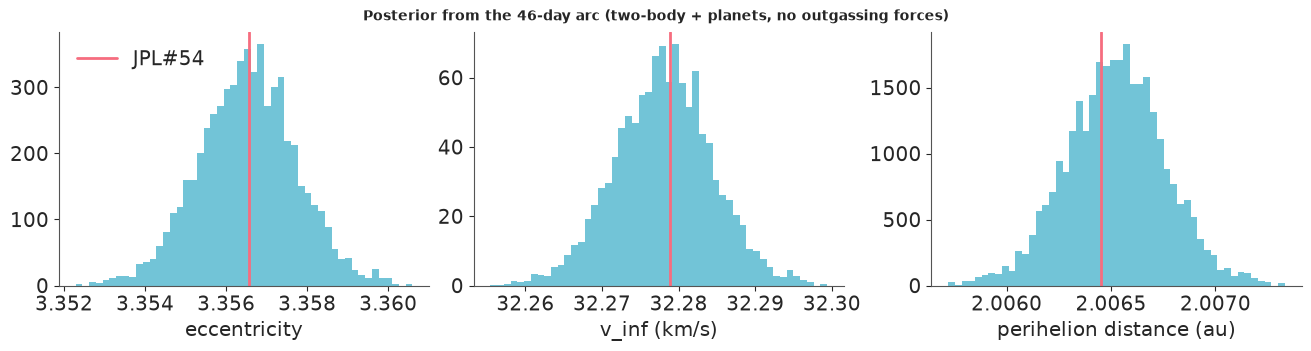

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, x, ref, lab in zip(axes, [e_s, v_s, q_s], [e_j, v_j, q_j],
                           ["eccentricity", "v_inf (km/s)", "perihelion distance (au)"]):
    ax.hist(x, bins=50, color="C0", alpha=0.7, density=True)
    ax.axvline(ref, color="C1", lw=2, label="JPL#54")
    ax.set(xlabel=lab)
axes[0].legend()
fig.suptitle("Posterior from the 46-day arc (two-body + planets, no outgassing forces)", fontsize=10);

The posterior agrees with JPL's solution to within its own width: eccentricity about 3.36 (an
ellipse has $e < 1$, a parabola exactly 1; this is a steep hyperbola), a speed "at infinity" of
32.3 km/s relative to the Sun, perihelion at 2.0 au in December 2019. With the full arc the question
"is $e > 1$?" is answered beyond any doubt; the interesting uncertainty was entirely in the first
week.

The fit also says something about the data: the stated uncertainties had to be scaled up by the
factor $s$ printed above, and the tails are heavy ($\nu$ between 3 and 4) - a Gaussian likelihood
would have been dragged around by the outliers below.

1.1% of residuals exceed 3 arcsec


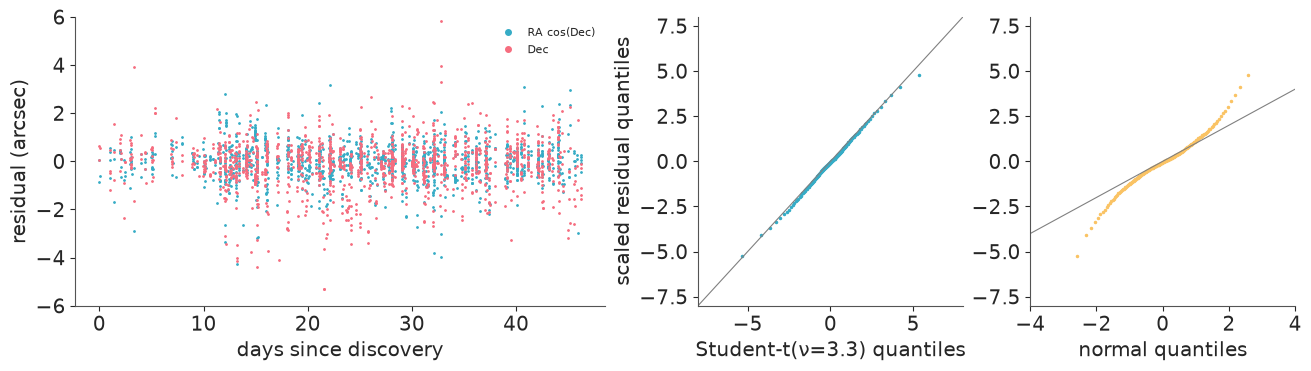

In [37]:
th_med = np.median(TH, axis=0)
r_med = np.asarray(resid_full(jnp.asarray(th_med))) * np.r_[sig, sig]
n = len(obs)
s_med = float(np.median(s_scale))
nu_med = float(idata_orbit.posterior["nu"].median())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"width_ratios": [2, 1, 1]})
ax = axes[0]
ax.plot(obs.day, r_med[:n], ".", ms=2, label="RA cos(Dec)")
ax.plot(obs.day, r_med[n:], ".", ms=2, label="Dec")
ax.set(ylim=(-6, 6), xlabel="days since discovery", ylabel="residual (arcsec)")
ax.legend(markerscale=4, fontsize=8)
z_ = np.r_[r_med[:n], r_med[n:]] / np.r_[sig, sig] / s_med
qs = np.linspace(0.005, 0.995, 199)
axes[1].plot(stats.t(nu_med).ppf(qs), np.quantile(z_, qs), ".", ms=3)
axes[1].plot([-8, 8], [-8, 8], color="0.5", lw=0.8)
axes[1].set(xlim=(-8, 8), ylim=(-8, 8), xlabel=f"Student-t(ν={nu_med:.1f}) quantiles", ylabel="scaled residual quantiles")
axes[2].plot(stats.norm.ppf(qs), np.quantile(z_, qs), ".", ms=3, color="C2")
axes[2].plot([-4, 4], [-4, 4], color="0.5", lw=0.8)
axes[2].set(xlim=(-4, 4), ylim=(-8, 8), xlabel="normal quantiles")
print(f"{np.mean(np.abs(r_med) > 3):.1%} of residuals exceed 3 arcsec");

The residuals scatter around zero over the whole arc without trends - a trend would be the signature
of a missing force, and the non-gravitational acceleration JPL fits over 1.6 years moves the comet by
only about a tenth of an arcsecond in 46 days (the comparison with JPL above). The quantile plots are the posterior predictive check of the noise model: against
the fitted Student-t the scaled residuals lie close to the line; against a normal distribution the
tails bend away - those points would have pulled a Gaussian fit.

### How long an arc did it take?

Now the question that mattered in September 2019. For arcs of 1, 2, 3, 5, 7 and 10 days after
discovery we map the posterior over the two unobserved quantities $(\log\rho, \dot\rho)$, using the
error model the full arc taught us (stated errors times $s$, Student-t with $\nu$, posterior medians).
At each node we find the best attributable (Gauss-Newton with Student-t weights) and integrate the
four attributable parameters out with the **Laplace approximation** (flat prior on them):

$$p(D \mid \rho, \dot\rho) \approx p(D \mid \hat a, \rho, \dot\rho)\,(2\pi)^2\,|H|^{-1/2}.$$

The prior is uniform in $\log\rho$ from 0.05 to 30 au and in $\dot\rho$ from -0.1 to +0.1 au/day
(±170 km/s) - it is deliberately *not* informed by what objects usually do.

A plain rectangular grid fails here, which is worth knowing: after a week the posterior is a thin
diagonal sliver, far narrower than any affordable grid spacing, and the best nodes of a coarse grid
are all *off* the ridge - a first version of this analysis zoomed in on the wrong place and reported
$e \approx 13$ from a 10-day arc. So `range_arc` maps in three passes: (1) a coarse grid over the
whole prior box (for the prior probability of $e > 1$ and starting values); (2) for 100 distances
spanning the plausible range, the range rate is optimised too (5 parameters, Levenberg-Marquardt),
which traces the ridge and its local width; (3) a **sheared grid** that, at each distance, spans ±6
conditional standard deviations of the range rate around the ridge (clipped to the prior), weighted
by its width. With JAX, each pass is a few vectorised calls over thousands of small optimisations.

In [38]:
tic = time.time()
ranging = {arc: range_arc(arc, scale=s_med, nu=nu_med) for arc in ARCS}
print(f"ranging for {len(ARCS)} arcs: {time.time() - tic:.0f} s")
rows = []
for arc, R_ in ranging.items():
    ph_, po_ = R_["prior_hyp"], R_["post_hyp"]
    ew = R_["e"].ravel()
    o = np.argsort(ew)
    cdf = np.cumsum(R_["post"].ravel()[o])
    e05, e50, e95 = (ew[o][np.searchsorted(cdf, q_)] for q_ in [0.05, 0.5, 0.95])
    po_bound = min(po_, 1 - 1e-15)
    rows.append({"arc (days)": arc, "positions": R_["n"], "prior P(e>1)": round(ph_, 3),
                 "posterior P(e>1)": f"{po_:.6f}",
                 "log10 Bayes factor (hyperbolic:bound)": (">" if po_ > 1 - 1e-15 else "")
                 + f"{np.log10(po_bound / (1 - po_bound)) - np.log10(ph_ / (1 - ph_)):.1f}",
                 "e: median [90% interval]": f"{e50:.3g} [{e05:.3g}, {e95:.3g}]"})
print(pd.DataFrame(rows).to_string(index=False))

ranging for 6 arcs: 38 s
 arc (days)  positions  prior P(e>1) posterior P(e>1) log10 Bayes factor (hyperbolic:bound) e: median [90% interval]
          1          5         0.854         0.939667                                   0.4    122 [0.853, 4.48e+03]
          2         11         0.854         0.900845                                   0.2    436 [0.741, 4.96e+03]
          3         25         0.854         0.997836                                   1.9     720 [12.6, 4.21e+03]
          5         43         0.854         0.994857                                   1.5        10.2 [2.26, 52.5]
          7         58         0.854         0.999998                                   4.8         5.2 [2.83, 9.84]
         10         85         0.855         1.000000                                 >14.2        2.86 [2.41, 3.37]


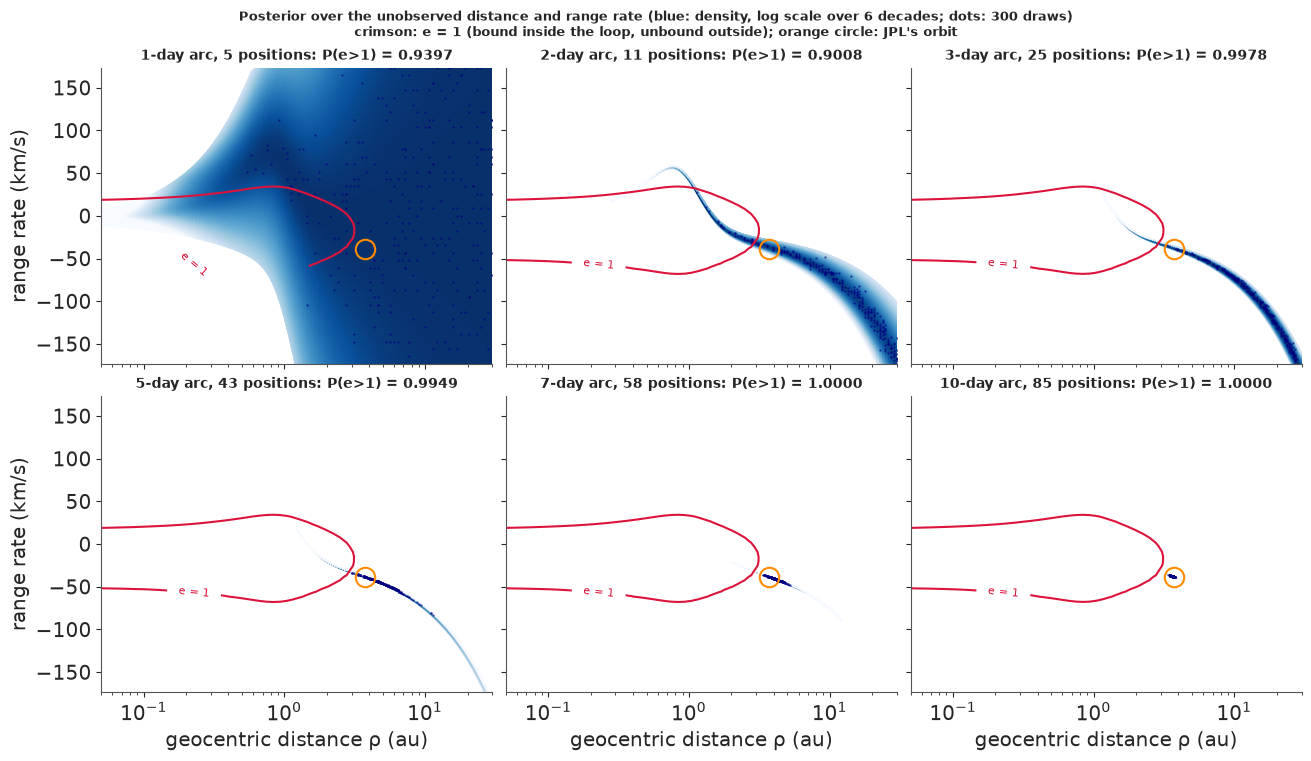

In [39]:
KMS = AU_KM / 86400
rho_j = np.linalg.norm(s_jpl[0] - E0)
rd_j = (s_jpl[0] - E0) @ (s_jpl[1] - VE0) / rho_j
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), sharex=True, sharey=True)
for ax, (arc, R_) in zip(axes.ravel(), ranging.items()):
    d = R_["dens"]
    ax.pcolormesh(np.exp(R_["L"]), R_["Rd"] * KMS, np.maximum(d, d.max() * 1e-7), cmap="Blues", shading="gouraud",
                  norm=LogNorm(vmin=d.max() * 1e-6, vmax=d.max()))
    pick = rng.choice(d.size, 300, p=R_["post"].ravel())
    ax.plot(np.exp(R_["L"].ravel()[pick]), R_["Rd"].ravel()[pick] * KMS, ".", ms=1.5, color="navy", alpha=0.5)
    cs = ax.contour(np.exp(R_["L1"]), R_["R1"] * KMS, R_["e1"], levels=[1.0], colors="crimson", linewidths=1.5)
    ax.clabel(cs, fmt={1.0: "e = 1"}, fontsize=8)
    ax.plot(rho_j, rd_j * KMS, "o", mfc="none", mec="darkorange", ms=14, mew=1.5)
    ax.set(xscale="log", title=f"{arc}-day arc, {R_['n']} positions: P(e>1) = {R_['post_hyp']:.4f}")
    ax.title.set_fontsize(10)
for ax in axes[1]:
    ax.set_xlabel("geocentric distance ρ (au)")
for ax in axes[:, 0]:
    ax.set_ylabel("range rate (km/s)")
fig.suptitle("Posterior over the unobserved distance and range rate (blue: density, log scale over 6 decades; dots: 300 "
             "draws)\ncrimson: e = 1 (bound inside the loop, unbound outside); orange circle: JPL's orbit", fontsize=9);

Read the panels and the table together.

* **After 1-2 days** the posterior covers most distances beyond about 1 au, each with its own range
  rate, on *both* sides of $e = 1$. The posterior probability of a hyperbolic orbit is 0.94 and 0.90 -
  high, but so is the *prior* probability, 0.85, because most of a broad box of velocities is above
  the escape speed. The **Bayes factor**, which compares the two, is 2.5 and 1.6 (log10 0.4 and 0.2):
  the data have not yet said anything about $e$. Reporting "P(e>1) = 0.94" after one night would be
  reporting the prior.
* **By 3-5 days** the curvature of the track (and the parallax between observatories) collapses the
  posterior onto a thin curved band that runs out of the bound region; the Bayes factor is about
  30-100. It does not grow monotonically (day 5 is lower than day 3): new positions can move mass
  either way. The eccentricity is still unknown within a factor of twenty (day 5: median 10, 90%
  interval 2.3 to 53) because the distance along the band is.
* **By 7-10 days** the band has shrunk to a short piece near JPL's orbit: Bayes factor $10^{4.8}$ at
  7 days and beyond $10^{14}$ (no grid node with $e < 1$ carries any weight) at 10 days, with
  $e$ = 2.9 (90% 2.4 to 3.4) - JPL's 3.36 from the full orbit sits at the upper edge of that interval.

The Bayes factor is what an astronomer should multiply by their prior odds. Before 2017 no
interstellar object was known among hundreds of thousands of catalogued small bodies, so prior odds of
something like $10^{-5}$ to $10^{-6}$ for any new comet would have been reasonable - which is why a
Bayes factor of a few after one night, or even 100 after a few, is not convincing, and why an arc of
a week or more is needed. (The Bayes factors depend on the prior box within each
hypothesis, the usual caveat; the conclusion from 10 days does not.)

### Where it came from, and where it goes

A hyperbolic orbit has two **asymptotes**: the direction it came from and the direction it leaves
in. The incoming one (the "radiant") points back toward where 2I was before it met the Sun.

incoming radiant: RA 32.821 ± 0.007 deg, Dec +59.459 ± 0.001 deg (JPL#54: RA 32.826, Dec +59.460)
2-day-arc draws: 1 of 30 bound; distances at discovery 2.82 to 30.0 au


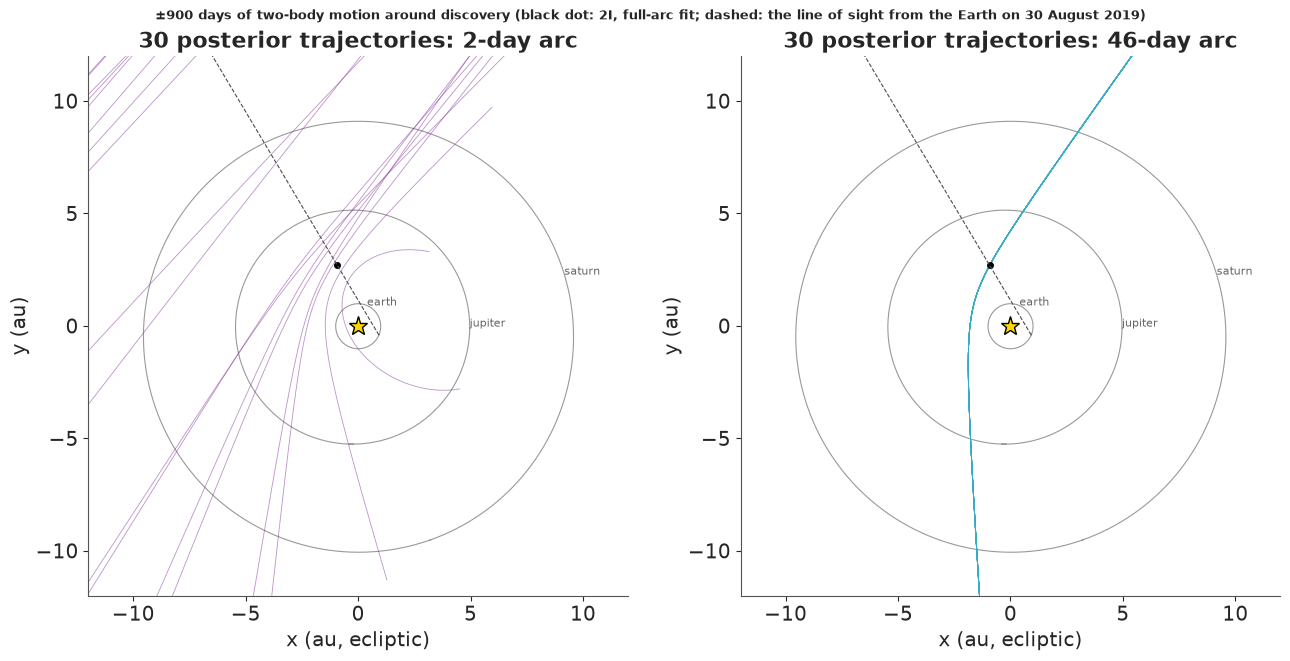

In [40]:
def radiant(r, v):
    """Direction (RA, Dec in degrees) from which a hyperbolic orbit arrives."""
    rn = np.linalg.norm(r, axis=-1, keepdims=True)
    hvec = np.cross(r, v)
    evec = np.cross(v, hvec) / GM_SUN - r / rn
    e = np.linalg.norm(evec, axis=-1, keepdims=True)
    ehat = evec / e
    phat = np.cross(hvec / np.linalg.norm(hvec, axis=-1, keepdims=True), ehat)
    th = np.arccos(-1 / e)                                # true anomaly of the asymptotes
    u = np.cos(th) * ehat - np.sin(th) * phat             # position direction at t -> -infinity
    return np.degrees(np.arctan2(u[..., 1], u[..., 0])) % 360, np.degrees(np.arcsin(u[..., 2]))


ra_rad, dec_rad = radiant(R0, V0)
ra_j, dec_j = radiant(*[x[None] for x in s_jpl])
print(f"incoming radiant: RA {ra_rad.mean():.3f} ± {ra_rad.std():.3f} deg, Dec {dec_rad.mean():+.3f} ± {dec_rad.std():.3f} deg "
      f"(JPL#54: RA {ra_j[0]:.3f}, Dec {dec_j[0]:+.3f})")


def two_body_track(r0, v0, days, h=1.0):
    """RK4 two-body tracks for many states at once (Sun only; for drawing)."""
    n = int(abs(days) / h)
    h = np.sign(days) * h
    r, v = r0.copy(), v0.copy()
    out = [r.copy()]
    a = lambda r_: -GM_SUN * r_ / np.linalg.norm(r_, axis=-1, keepdims=True) ** 3
    for _ in range(n):
        k1r, k1v = v, a(r)
        k2r, k2v = v + h / 2 * k1v, a(r + h / 2 * k1r)
        k3r, k3v = v + h / 2 * k2v, a(r + h / 2 * k2r)
        k4r, k4v = v + h * k3v, a(r + h * k3r)
        r = r + h / 6 * (k1r + 2 * k2r + 2 * k3r + k4r)
        v = v + h / 6 * (k1v + 2 * k2v + 2 * k3v + k4v)
        out.append(r.copy())
    return np.array(out)


def to_ecliptic(x):
    c, s = np.cos(OBLIQ), np.sin(OBLIQ)
    return np.stack([x[..., 0], c * x[..., 1] + s * x[..., 2], -s * x[..., 1] + c * x[..., 2]], -1)


def track(r0, v0, back=900, fwd=900):
    b_ = two_body_track(r0, v0, -back, 2.0)[::-1]
    f_ = two_body_track(r0, v0, fwd, 2.0)[1:]
    return to_ecliptic(np.concatenate([b_, f_]))


# posterior orbits: full arc, and the 2-day arc (drawn from its ranging grid)
full_tr = track(R0[:30], V0[:30])
R2 = ranging[2]
pick = rng.choice(R2["post"].size, 30, p=R2["post"].ravel())
st2 = jax.vmap(state_from)(jnp.asarray(np.c_[R2["att"][pick], R2["L"].ravel()[pick], R2["Rd"].ravel()[pick]]))
tr3 = track(np.asarray(st2[0]), np.asarray(st2[1]))
e2 = elements(np.asarray(st2[0]), np.asarray(st2[1]))[0]
print(f"2-day-arc draws: {np.sum(e2 < 1)} of 30 bound; distances at discovery {np.exp(R2['L'].ravel()[pick]).min():.2f} "
      f"to {np.exp(R2['L'].ravel()[pick]).max():.1f} au")
planets = {}
for b_, per in [("earth", 365.25), ("jupiter", 4332.6), ("saturn", 10759.2)]:
    r0_ = hermite(TAB[b_], np.array([T_EPOCH]))
    v0_ = hermite(TAB[b_], np.array([T_EPOCH]), deriv=True)
    planets[b_] = to_ecliptic(two_body_track(r0_, v0_, per * 1.01, per / 360))[:, 0]

E_ecl = to_ecliptic(E0)
u_sight = to_ecliptic(R0[0] - E0) / np.linalg.norm(R0[0] - E0)
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, (tr_, lab, col) in zip(axes, [(tr3, "2-day arc", "C3"), (full_tr, "46-day arc", "C0")]):
    for p_, x in planets.items():
        ax.plot(x[:, 0], x[:, 1], color="0.6", lw=0.8)
        ax.text(x[90, 0], x[90, 1], p_, color="0.4", fontsize=8)
    for i in range(tr_.shape[1]):
        ax.plot(tr_[:, i, 0], tr_[:, i, 1], color=col, lw=0.6, alpha=0.5)
    ax.plot(0, 0, "*", color="gold", ms=14, mec="k")
    r_now = to_ecliptic(R0[:1])[0]
    ax.plot(r_now[0], r_now[1], "o", color="k", ms=4)
    ax.plot(*np.c_[E_ecl[:2], E_ecl[:2] + 30 * u_sight[:2]], ls="--", color="0.3", lw=0.8)
    ax.set(xlim=(-12, 12), ylim=(-12, 12), aspect="equal", xlabel="x (au, ecliptic)", ylabel="y (au)",
           title=f"30 posterior trajectories: {lab}")
fig.suptitle("±900 days of two-body motion around discovery (black dot: 2I, full-arc fit; dashed: the line of sight "
             "from the Earth on 30 August 2019)", fontsize=9);

On the left, 30 orbits drawn from the 2-day posterior. Each crosses the dashed line of sight at its own
distance (between about 3 au and the prior's 30 au limit for these draws); most are nearly straight
lines - fast, strongly hyperbolic orbits of distant objects - and one of the 30 is bound. That is what a
posterior dominated by prior volume looks like. On the right, the full-arc posterior: the 30
trajectories are indistinguishable at this scale. The drawing uses two-body motion; over ±2.5 years
the planets would bend it only slightly.

The same picture in 3-D (drag to rotate): the hyperbola is inclined 44 degrees to the planets' plane
and passes the Sun outside the orbit of Mars.

In [41]:
figp = go.Figure()
for p_, x in planets.items():
    figp.add_trace(go.Scatter3d(x=x[:, 0], y=x[:, 1], z=x[:, 2], mode="lines", line=dict(color="grey", width=2), name=p_))
for i in range(12):
    figp.add_trace(go.Scatter3d(x=tr3[::3, i, 0], y=tr3[::3, i, 1], z=tr3[::3, i, 2], mode="lines",
                                line=dict(color="rgba(214,39,40,0.5)", width=2), name="2-day arc", showlegend=i == 0))
for i in range(12):
    figp.add_trace(go.Scatter3d(x=full_tr[::3, i, 0], y=full_tr[::3, i, 1], z=full_tr[::3, i, 2], mode="lines",
                                line=dict(color="rgba(31,119,180,0.8)", width=3), name="46-day arc", showlegend=i == 0))
figp.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode="markers", marker=dict(size=6, color="gold"), name="Sun"))
figp.update_layout(height=600, scene=dict(xaxis=dict(range=[-12, 12]), yaxis=dict(range=[-12, 12]),
                                          zaxis=dict(range=[-12, 12]), aspectmode="cube"),
                   title="2I/Borisov: posterior trajectories after 2 and 46 days (ecliptic frame, au)")
figp.show()
print(f"total run time {time.time() - T_START:.0f} s")

total run time 333 s


## Summary

* **A transit search is a matched filter over a huge grid.** Box least squares over 300,000 periods
  found Kepler-10b at SNR 170 and, after masking it, Kepler-10c at SNR 98, although a single transit
  of b has an SNR of only 5. Significance has to be judged against the maximum of a *noise search*:
  scrambled light curves and a Gumbel posterior put the 1% false-alarm threshold at SNR 7.7 (90%:
  7.3-8.6).
* **Detrending can eat the signal.** A sliding filter shorter than a few transit durations removed most
  of 10c's depth, and even the 1-day filter took 10%. Fitting local baselines *jointly* with the
  transit, integrated out analytically, avoids the problem and 5,000 nuisance parameters.
* **A hand-written physical model must be tested.** Our limb-darkened transit (quadrature over the
  covered area, tabulated and interpolated inside PyMC) matches exact and brute-force references to
  better than a millionth of the depth; long-cadence supersampling needed 11 sub-steps for 10b.
* **Parameterise by what the data measure.** Fitting 10c alone in (density, $b$) failed ($\hat R$ 1.18,
  divergences); in (duration, $b$) it sampled cleanly and showed the real impact parameter - density
  degeneracy. Asteroseismology supplies the density: radii 1.47 and 2.35 Earth radii, consistent
  with published work (with uncertainties somewhat optimistic because of mildly red noise, $\beta$ ≈ 1.3).
* **False-positive checks are model expansions.** Odd/even depths agree; the occultation of 10b is
  detected at 6.0 ± 0.9 ppm - planet light, not a star - and the phase curve shows up in the light
  curve; no grazing geometry is allowed.
* **Non-detections need an efficiency.** Injection-recovery with a Bayesian logistic curve: 50%
  recovery at an expected SNR of 10, i.e. planets of 0.6 (10 days) to 0.9 (100 days) Earth radii; no
  further transiting planet above about 1 Earth radius inside 100 days.
* **Orbits from angles: the distance is the unknown.** For 2I/Borisov the full 46-day arc gives
  $e$ = 3.357 ± 0.001 and $v_\infty$ = 32.28 km/s, matching JPL within 0.3 posterior sd, with a
  Student-t likelihood that learned heavy tails ($\nu$ ≈ 3.3) and errors twice those reported. Mapping
  the unobserved distance and range rate for short arcs shows that after one or two nights
  "P(e > 1) ≈ 0.9" merely repeats the prior (Bayes factor 1.6-2.5), that it takes about a week for the
  evidence to become overwhelming - and that a naive rectangular grid gets this wrong.

## Try it yourself

1. **A false positive.** Pick a KOI whose disposition in the Exoplanet Archive's cumulative KOI table
   is "FALSE POSITIVE" with the "significant secondary" flag set, download its light curve from MAST as
   in `tools/build_e78_exoplanets.py`, and run Parts B-D on it. Does the odd/even term or the
   occultation term flag it? What happens to $k$ and $b$ when
   the model is forced to explain a stellar eclipse?
2. **Red noise.** Replace the white-noise marginal likelihood by a Gaussian process in each window
   (a Matérn-3/2 kernel with shared hyperparameters; each window is small, so exact Cholesky is fine).
   How much do the uncertainties on $k$ and on the occultation depth grow, and does the binned-rms
   check improve?
3. **'Oumuamua.** Fetch the MPC astrometry of 1I/'Oumuamua (2017) and repeat Part F. Then add a
   radial non-gravitational acceleration $A_1 (1\,\text{au}/r)^2$ to the integrator and compare the
   models - with LOO on the Student-t residuals, or a Bayes factor from the Laplace evidence. The
   published analysis (Micheli et al. 2018) found the non-gravitational term necessary; do you, and
   how sensitive is the answer to the error model?